# MODELO CHURN - CLIENTES - SOPORTE

## HIPÓTESIS 

H1: Los clientes con un mayor número de interacciones con soporte presentan una mayor probabilidad de churn.

H2: LEl churn presenta diferencias según el tipo de zona geográfica del cliente.

H3: Los clientes de zonas rurales presentan una mayor probabilidad de churn que los clientes de zonas urbanas.

H4: Los clientes con planes de prepago presentan una mayor probabilidad de churn que los clientes con planes premium.


In [1]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier



warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
df_churn= pd.read_csv(r"C:\Users\ancar\Documents\Prácticas\UCV-Churn\data\raw\churn_target.csv")
df_churn

,cliente_id,fecha,churn
0,C000001,2023-01-01,0
1,C000001,2023-02-01,0
2,C000001,2023-03-01,0
3,C000001,2023-04-01,0
4,C000001,2023-05-01,0
...,...,...,...
321982,C010000,2025-08-01,0
321983,C010000,2025-09-01,0
321984,C010000,2025-10-01,0
321985,C010000,2025-11-01,0


In [3]:
df_clientes= pd.read_csv(r"C:\Users\ancar\Documents\Prácticas\UCV-Churn\data\raw\clientes.csv")
df_clientes.head()

,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo
0,C000001,Z26,Oeste,urbana_premium,107159,18.00,M,Soltero/a,2,Prepago,Gama alta,"4,335.00",72.00,0
1,C000002,Z15,Oeste,suburbana,62939,54.00,M,Casado/a,2,Premium,Gama media,"4,609.00",35.00,1
2,C000003,Z27,Norte,suburbana,42704,54.00,M,Casado/a,3,Prepago,Gama baja,"1,836.00",11.00,0
3,C000004,Z22,Este,suburbana,53534,34.00,M,Soltero/a,1,Prepago,Gama media,"2,318.00",13.00,0
4,C000005,Z04,Centro,suburbana,55457,46.00,F,Soltero/a,2,Contrato,Gama media,"2,184.00",21.00,0


In [4]:
df_soporte= pd.read_csv(r"C:\Users\ancar\Documents\Prácticas\UCV-Churn\data\raw\interacciones_soporte.csv")
df_soporte.head()

,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
0,I923052492930,C000001,2023-02-07,2023-02-01,telefono,Facturación,9.50,0,4.00,0.41,0,0,0
1,I692361171059,C000001,2023-04-20,2023-04-01,app_chat,Facturación,3.90,1,4.00,0.43,0,0,0
2,I354109146175,C000001,2023-04-27,2023-04-01,app_chat,Baja / portabilidad,2.80,1,5.00,0.43,0,0,0
3,I986032353420,C000001,2023-05-04,2023-05-01,telefono,Consulta general,8.40,1,3.00,0.45,0,0,0
4,I553023863181,C000001,2023-06-26,2023-06-01,telefono,Impago / pago,4.50,1,4.00,0.39,0,0,0


In [5]:
df_churn.isnull().sum()

cliente_id    0
fecha         0
churn         0
dtype: int64

In [6]:
df_churn['churn'].value_counts()

churn
0    319987
1      2000
Name: count, dtype: int64

In [7]:
df_churn.duplicated().sum()

np.int64(0)

### ELIMINACIÓN DUPLICADOS CLIENTES

In [8]:
df_clientes.duplicated().sum()

np.int64(150)

In [9]:
df_clientes['cliente_id'].duplicated().sum()

np.int64(150)

In [10]:
df_clientes[
    df_clientes['cliente_id'].duplicated(keep=False)
].sort_values('cliente_id')

,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo
5,C000006,Z30,Centro,suburbana,33966,37.00,M,Casado/a,3,Prepago,Gama media,"2,411.00",86.00,0
10033,C000006,Z30,Centro,suburbana,33966,37.00,M,Casado/a,3,Prepago,Gama media,"2,411.00",86.00,0
87,C000088,Z16,Este,urbana_premium,72683,18.00,M,Soltero/a,3,Contrato,Gama media,"2,492.00",25.00,0
10130,C000088,Z16,Este,urbana_premium,72683,18.00,M,Soltero/a,3,Contrato,Gama media,"2,492.00",25.00,0
100,C000101,Z28,Sur,urbana_premium,64486,22.00,M,Soltero/a,2,Premium,Gama alta,"4,181.00",NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9856,C009857,Z21,Centro,rural,19103,52.00,F,Casado/a,2,Prepago,Gama baja,"2,553.00",41.00,0
10032,C009898,Z26,Oeste,urbana_premium,107159,26.00,?,Soltero/a,3,Premium,Gama media,"4,275.00",7.00,1
9897,C009898,Z26,Oeste,urbana_premium,107159,26.00,?,Soltero/a,3,Premium,Gama media,"4,275.00",7.00,1
10062,C009950,Z17,Sur,suburbana,56619,37.00,X,Soltero/a,1,Premium,Gama media,"3,569.00",65.00,1


In [11]:
df_clientes = df_clientes.drop_duplicates()

In [12]:
df_clientes.isnull().sum()

cliente_id            0
zona_id               0
region                0
tipo_zona             0
poblacion_zona        0
edad                300
sexo                 45
estado_civil         77
num_lineas            0
tipo_plan             0
tipo_dispositivo      0
ingreso_estimado    300
antiguedad_meses    300
descuento_activo      0
dtype: int64

### ELIMINACIÓN NULOS CSV CLIENTES

In [13]:
df_clientes.describe()

,poblacion_zona,edad,num_lineas,ingreso_estimado,antiguedad_meses,descuento_activo
count,"10,000.00","9,700.00","10,000.00","9,700.00","9,700.00","10,000.00"
mean,"60,004.60",39.34,2.31,"3,476.79",32.55,0.26
std,"28,724.37",11.97,1.02,"1,411.89",22.53,0.44
min,"11,707.00",18.00,1.00,900.00,-110.00,0.00
25%,"41,163.00",31.00,2.00,"2,466.00",18.00,0.00
50%,"56,342.00",39.00,2.00,"3,219.00",29.00,0.00
75%,"72,683.00",47.00,3.00,"4,194.25",44.00,1.00
max,"107,159.00",80.00,5.00,"12,000.00",120.00,1.00


In [14]:
df_clientes['edad'] = df_clientes['edad'].fillna(
    df_clientes['edad'].median()
)

In [15]:
df_clientes['ingreso_estimado'] = df_clientes['ingreso_estimado'].fillna(
    df_clientes['ingreso_estimado'].median()
)

In [16]:
df_clientes['antiguedad_meses'] = df_clientes['antiguedad_meses'].fillna(
    df_clientes['antiguedad_meses'].median()
)

In [17]:
df_clientes['sexo'] = df_clientes['sexo'].fillna('Desconocido')

In [18]:
df_clientes['estado_civil'] = df_clientes['estado_civil'].fillna('Desconocido')

In [19]:
df_clientes.isnull().sum()

cliente_id          0
zona_id             0
region              0
tipo_zona           0
poblacion_zona      0
edad                0
sexo                0
estado_civil        0
num_lineas          0
tipo_plan           0
tipo_dispositivo    0
ingreso_estimado    0
antiguedad_meses    0
descuento_activo    0
dtype: int64

In [20]:
df_soporte.duplicated().sum()

np.int64(4558)

In [21]:
duplicados = df_soporte[
    df_soporte['interaccion_id'].duplicated(
        keep=False
    )
]

duplicados.head(20)

,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
212,I716491295118,C000007,2023-06-01,2023-06-01,tienda,Consulta general,13.00,0,2.00,0.39,0,0,0
248,I271008632610,C000008,2023-10-04,2023-10-01,telefono,Cambio de plan,4.10,1,5.00,0.41,0,0,0
255,I831660710653,C000008,2024-04-25,2024-04-01,app_chat,Calidad de señal,8.00,1,3.00,0.30,0,0,0
317,I666962040807,C000010,2025-08-20,2025-08-01,telefono,Consulta general,4.90,0,5.00,0.40,0,0,0
326,I721437122731,C000011,2023-04-14,2023-04-01,telefono,Baja / portabilidad,10.80,0,3.00,0.54,0,0,0
444,I747915945768,C000013,2025-06-15,2025-06-01,tienda,Calidad de señal,1.00,1,5.00,0.36,0,0,0
563,I705123563177,C000017,2024-08-25,2024-08-01,tienda,Facturación,2.60,0,3.00,0.48,0,1,41
572,I801443917956,C000018,2023-04-15,2023-04-01,app_chat,Calidad de señal,3.70,1,3.00,0.52,0,0,0
579,I748444381545,C000018,2023-09-16,2023-09-01,telefono,Cobertura / velocidad,1.20,0,2.00,0.54,0,0,0
725,I389032705098,C000023,2023-08-10,2023-08-01,app_chat,Impago / pago,7.30,1,4.00,0.39,0,1,28


In [22]:
df_soporte[
    df_soporte['interaccion_id'] == 'I716491295118'
]

,interaccion_id,cliente_id,fecha_evento,mes,canal,motivo,duracion_min,resuelto,satisfaccion_post,stress_calidad_lag,incidencia_masiva_lag,impago_mes,dias_retraso_mes
212,I716491295118,C000007,2023-06-01,2023-06-01,tienda,Consulta general,13.00,0,2.00,0.39,0,0,0
303947,I716491295118,C000007,2023-06-01,2023-06-01,tienda,Consulta general,13.00,0,2.00,0.39,0,0,0


In [23]:
df_soporte = df_soporte.drop_duplicates()

In [24]:
df_soporte['interaccion_id'].duplicated().sum()

np.int64(0)

### ELIMINAR NULOS DEL CSV DE SOPORTE

In [25]:
df_soporte['interaccion_id'].duplicated().sum()

np.int64(0)

In [26]:
df_soporte.isnull().sum()

interaccion_id              0
cliente_id                  0
fecha_evento                0
mes                         0
canal                       0
motivo                   4558
duracion_min                0
resuelto                    0
satisfaccion_post        4558
stress_calidad_lag          0
incidencia_masiva_lag       0
impago_mes                  0
dias_retraso_mes            0
dtype: int64

### ELIMINACIÓN NULOS DEL CSV DE SOPORTE


In [27]:
df_soporte['motivo'] = df_soporte['motivo'].fillna('Desconocido')

In [28]:
df_soporte['sin_satisfaccion'] = (
    df_soporte['satisfaccion_post']
    .isnull()
    .astype(int)
)

In [29]:
df_soporte['satisfaccion_post'] = (
    df_soporte['satisfaccion_post']
    .fillna(-1)
)

La variable satisfaccion_post presentaba valores faltantes asociados probablemente a clientes que no respondieron la encuesta posterior a la interacción. En lugar de eliminar registros, se decidió conservar la información creando una categoría diferenciada para ausencia de respuesta, evitando así pérdida innecesaria de datos.

In [30]:
df_soporte.isnull().sum()

interaccion_id           0
cliente_id               0
fecha_evento             0
mes                      0
canal                    0
motivo                   0
duracion_min             0
resuelto                 0
satisfaccion_post        0
stress_calidad_lag       0
incidencia_masiva_lag    0
impago_mes               0
dias_retraso_mes         0
sin_satisfaccion         0
dtype: int64

## Granularidad -

 Que representa cada fila del dataset

*Churn*: Clientes/mes

*Cliente*: Cliente

*Soporte*: Cliente/ Interacción con soporte

In [31]:
# Vamos a convertir soporte a clientes-mes

soporte_cliente = (
    df_soporte.groupby('cliente_id')
    .agg({
        'interaccion_id':'count',
        'duracion_min':'mean',
        'resuelto':'mean',
        'satisfaccion_post':'mean'
    })
    .reset_index()
)

In [32]:
soporte_cliente.rename(columns={
    'interaccion_id':'num_interacciones_total',
    'duracion_min':'duracion_media',
    'resuelto':'pct_resuelto',
    'satisfaccion_post':'satisfaccion_media'
}, inplace=True)

In [33]:
soporte_cliente = soporte_cliente.merge(
    df_clientes[
        ['cliente_id', 'antiguedad_meses']
    ],
    on='cliente_id',
    how='left'
)

In [34]:
soporte_cliente['interacciones_por_mes'] = (
    soporte_cliente['num_interacciones_total']
    / soporte_cliente['antiguedad_meses']
)

In [35]:
soporte_cliente[
    'interacciones_por_mes'
] = (
    soporte_cliente[
        'interacciones_por_mes'
    ]
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)

In [36]:
churn_cliente = (
    df_churn.groupby('cliente_id')['churn']
    .max()
    .reset_index()
)

In [37]:
df_modelo_final = churn_cliente.merge(
    df_clientes,
    on='cliente_id',
    how='left'
)

In [38]:
df_modelo_final = df_modelo_final.merge(
    soporte_cliente,
    on='cliente_id',
    how='left'
)

In [39]:
cols_soporte = [
    'num_interacciones_total',
    'duracion_media',
    'pct_resuelto',
    'satisfaccion_media',
    'interacciones_por_mes'
]

df_modelo_final[cols_soporte] = (
    df_modelo_final[cols_soporte]
    .fillna(0)
)

In [40]:
df_modelo_final.duplicated().sum()

np.int64(0)

In [41]:
df_modelo_final.isnull().sum()

cliente_id                  0
churn                       0
zona_id                     0
region                      0
tipo_zona                   0
poblacion_zona              0
edad                        0
sexo                        0
estado_civil                0
num_lineas                  0
tipo_plan                   0
tipo_dispositivo            0
ingreso_estimado            0
antiguedad_meses_x          0
descuento_activo            0
num_interacciones_total     0
duracion_media              0
pct_resuelto                0
satisfaccion_media          0
antiguedad_meses_y         27
interacciones_por_mes       0
dtype: int64

In [42]:
df_modelo_final = df_modelo_final.drop(
    columns=['antiguedad_meses_y']
)

In [43]:
df_modelo_final = df_modelo_final.rename(
    columns={
        'antiguedad_meses_x':'antiguedad_meses'
    }
)

In [44]:
df_modelo_final.isnull().sum()

cliente_id                 0
churn                      0
zona_id                    0
region                     0
tipo_zona                  0
poblacion_zona             0
edad                       0
sexo                       0
estado_civil               0
num_lineas                 0
tipo_plan                  0
tipo_dispositivo           0
ingreso_estimado           0
antiguedad_meses           0
descuento_activo           0
num_interacciones_total    0
duracion_media             0
pct_resuelto               0
satisfaccion_media         0
interacciones_por_mes      0
dtype: int64

# VISUALIZACIÓN VARIABLES

H1: Los clientes con un mayor número de interacciones con soporte presentan una mayor probabilidad de churn.

H2: LEl churn presenta diferencias según el tipo de zona geográfica del cliente.

H3: Los clientes de zonas rurales presentan una mayor probabilidad de churn que los clientes de zonas urbanas.

H4: Los clientes con planes de prepago presentan una mayor probabilidad de churn que los clientes con planes premium.


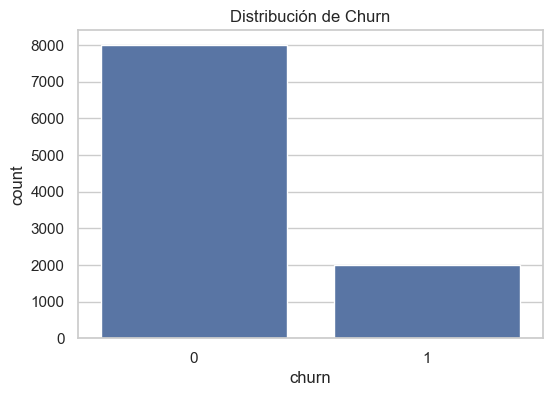

In [45]:


plt.figure(figsize=(6, 4))
sns.countplot(data=df_modelo_final, x='churn')
plt.title('Distribución de Churn')
plt.show()


In [46]:
df_modelo_final.describe()

,churn,poblacion_zona,edad,num_lineas,ingreso_estimado,antiguedad_meses,descuento_activo,num_interacciones_total,duracion_media,pct_resuelto,satisfaccion_media,interacciones_por_mes
count,"10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00","10,000.00"
mean,0.20,"60,004.60",39.33,2.31,"3,469.05",32.44,0.26,30.39,6.00,0.58,3.38,1.43
std,0.40,"28,724.37",11.79,1.02,"1,391.25",22.19,0.44,12.51,0.90,0.11,0.31,2.09
min,0.00,"11,707.00",18.00,1.00,900.00,-110.00,0.00,0.00,0.00,0.00,0.00,-16.50
25%,0.00,"41,163.00",31.00,2.00,"2,488.00",18.00,0.00,22.00,5.52,0.51,3.24,0.56
50%,0.00,"56,342.00",39.00,2.00,"3,219.00",29.00,0.00,30.00,6.03,0.58,3.39,0.96
75%,0.00,"72,683.00",47.00,3.00,"4,157.25",44.00,1.00,38.00,6.51,0.65,3.55,1.66
max,1.00,"107,159.00",80.00,5.00,"12,000.00",120.00,1.00,82.00,14.10,1.00,5.00,58.00


In [47]:
df_modelo_final[
    df_modelo_final['antiguedad_meses'] < 0
]

,cliente_id,churn,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo,num_interacciones_total,duracion_media,pct_resuelto,satisfaccion_media,interacciones_por_mes
31,C000032,0,Z29,Oeste,urbana_premium,67334,36.00,M,Casado/a,5,Premium,Gama baja,"2,525.00",-87.00,0,32.00,6.15,0.53,3.50,-0.37
142,C000143,0,Z29,Oeste,urbana_premium,67334,28.00,F,Soltero/a,2,Premium,Gama baja,"4,227.00",-48.00,0,19.00,6.09,0.68,3.74,-0.40
156,C000157,0,Z09,Norte,urbana_premium,102625,45.00,F,Soltero/a,3,Premium,Gama alta,"6,397.00",-37.00,1,20.00,6.83,0.55,3.45,-0.54
234,C000235,0,Z29,Oeste,urbana_premium,67334,33.00,F,Soltero/a,2,Prepago,Gama media,"2,426.00",-43.00,0,25.00,4.71,0.56,3.28,-0.58
578,C000579,0,Z27,Norte,suburbana,42704,34.00,M,Soltero/a,2,Prepago,Gama baja,"1,781.00",-18.00,0,48.00,6.20,0.60,3.52,-2.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9839,C009840,0,Z29,Oeste,urbana_premium,67334,43.00,F,Casado/a,4,Prepago,Gama alta,"4,631.00",-28.00,0,29.00,7.43,0.62,3.69,-1.04
9901,C009902,0,Z07,Centro,rural,15473,48.00,F,Casado/a,2,Contrato,Gama media,"2,215.00",-17.00,0,34.00,7.04,0.44,3.26,-2.00
9905,C009906,0,Z22,Este,suburbana,53534,56.00,M,Casado/a,2,Premium,Gama alta,"4,210.00",-27.00,0,45.00,5.80,0.51,3.16,-1.67
9909,C009910,0,Z27,Norte,suburbana,42704,61.00,F,Soltero/a,1,Premium,Gama alta,"3,705.00",-44.00,0,34.00,6.88,0.59,3.68,-0.77


In [48]:
df_modelo_final = df_modelo_final[
    df_modelo_final['antiguedad_meses'] >= 0
]

df_modelo_final['interacciones_por_mes'] = (
    df_modelo_final['num_interacciones_total']
    / df_modelo_final['antiguedad_meses']
)

df_modelo_final['interacciones_por_mes'] = (
    df_modelo_final['interacciones_por_mes']
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)

In [49]:
df_modelo_final.describe()

,churn,poblacion_zona,edad,num_lineas,ingreso_estimado,antiguedad_meses,descuento_activo,num_interacciones_total,duracion_media,pct_resuelto,satisfaccion_media,interacciones_por_mes
count,"9,855.00","9,855.00","9,855.00","9,855.00","9,855.00","9,855.00","9,855.00","9,855.00","9,855.00","9,855.00","9,855.00","9,855.00"
mean,0.20,"60,035.10",39.32,2.30,"3,468.85",33.42,0.26,30.36,6.00,0.58,3.38,1.48
std,0.40,"28,691.34",11.81,1.02,"1,392.56",20.67,0.44,12.50,0.90,0.11,0.31,2.06
min,0.00,"11,707.00",18.00,1.00,900.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,"41,163.00",31.00,2.00,"2,487.00",18.00,0.00,22.00,5.52,0.51,3.24,0.58
50%,0.00,"56,342.00",39.00,2.00,"3,219.00",29.00,0.00,30.00,6.03,0.58,3.39,0.97
75%,0.00,"72,683.00",47.00,3.00,"4,158.50",44.00,1.00,38.00,6.51,0.65,3.55,1.67
max,1.00,"107,159.00",80.00,5.00,"12,000.00",120.00,1.00,82.00,14.10,1.00,5.00,58.00


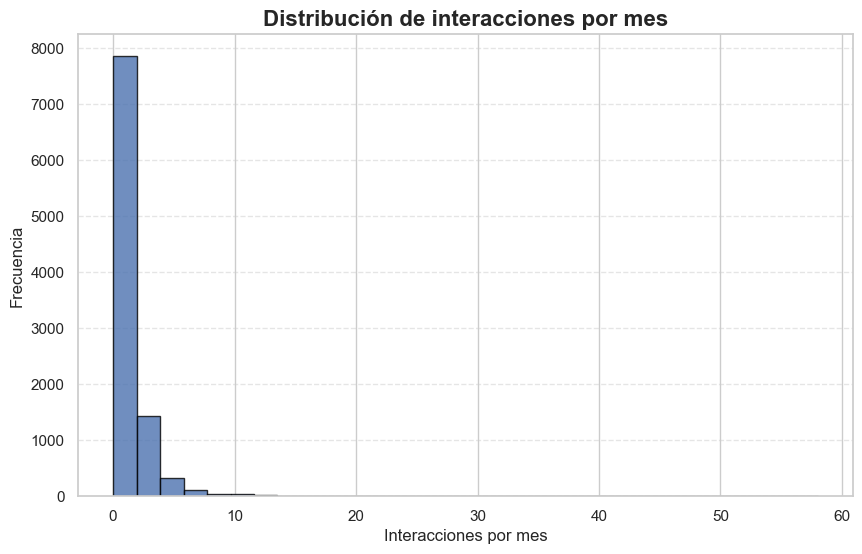

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.hist(
    df_modelo_final['interacciones_por_mes'],
    bins=30,
    edgecolor='black',
    alpha=0.8)

plt.title(
    'Distribución de interacciones por mes',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel(
    'Interacciones por mes',
    fontsize=12
)

plt.ylabel(
    'Frecuencia',
    fontsize=12
)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.show()

In [51]:
df_modelo_final['tipo_plan'].value_counts()

tipo_plan
Premium     4984
Prepago     2638
Contrato    2233
Name: count, dtype: int64

In [52]:
df_modelo_final['tipo_zona'].value_counts()

tipo_zona
urbana_premium    4420
suburbana         3977
rural             1458
Name: count, dtype: int64

In [53]:
df_modelo_final['region'].value_counts()

region
Oeste     2970
Este      2377
Sur       1825
Norte     1499
Centro    1184
Name: count, dtype: int64

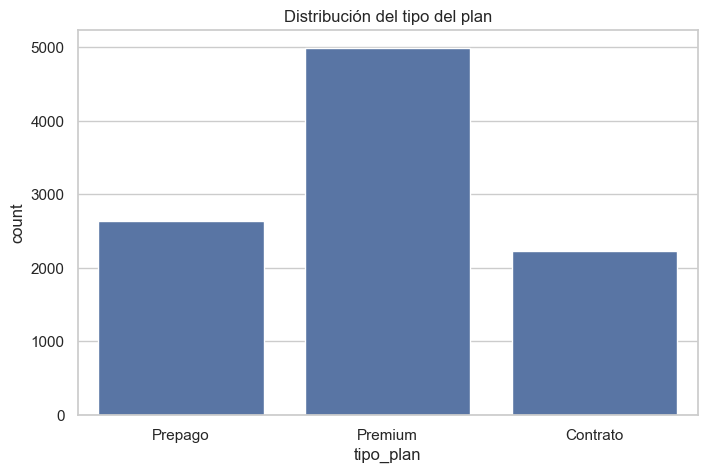

In [54]:
plt.figure(figsize=(8, 5))
# Cambia 'nombre_columna' por la variable que quieras mirar
sns.countplot(data=df_modelo_final, x='tipo_plan')

plt.title('Distribución del tipo del plan')
#plt.xticks(rotation=45) # Esto rota el texto de abajo por si las palabras son muy largas
plt.show()


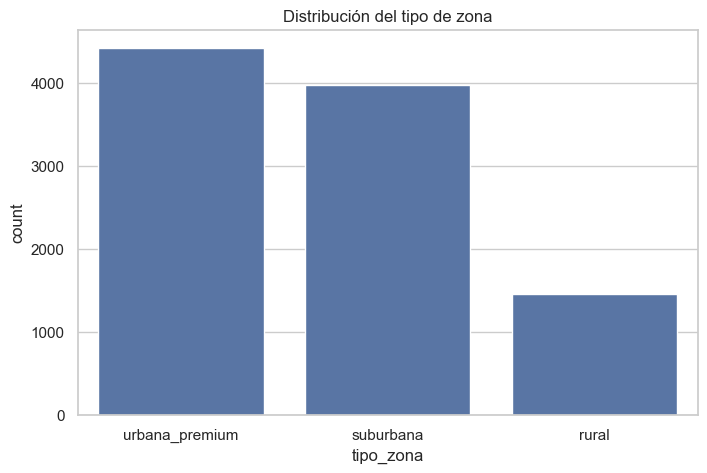

In [55]:
plt.figure(figsize=(8, 5))
# Cambia 'nombre_columna' por la variable que quieras mirar
sns.countplot(data=df_modelo_final, x='tipo_zona')

plt.title('Distribución del tipo de zona')
#plt.xticks(rotation=45) # Esto rota el texto de abajo por si las palabras son muy largas
plt.show()


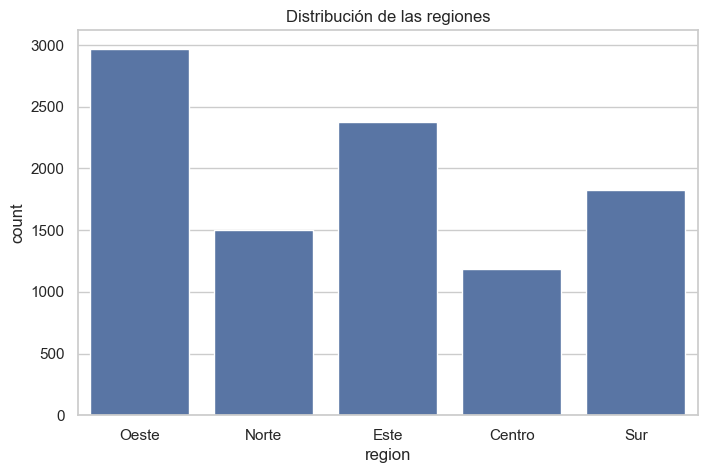

In [56]:
plt.figure(figsize=(8, 5))
# Cambia 'nombre_columna' por la variable que quieras mirar
sns.countplot(data=df_modelo_final, x='region')

plt.title('Distribución de las regiones')
#plt.xticks(rotation=45) # Esto rota el texto de abajo por si las palabras son muy largas
plt.show()

In [57]:
### ANÁLISIS BIVARIADO

In [58]:
df_modelo_final.groupby(
    'tipo_plan'
)['churn'].mean().sort_values(
    ascending=False
)

tipo_plan
Prepago    0.26
Contrato   0.21
Premium    0.16
Name: churn, dtype: float64

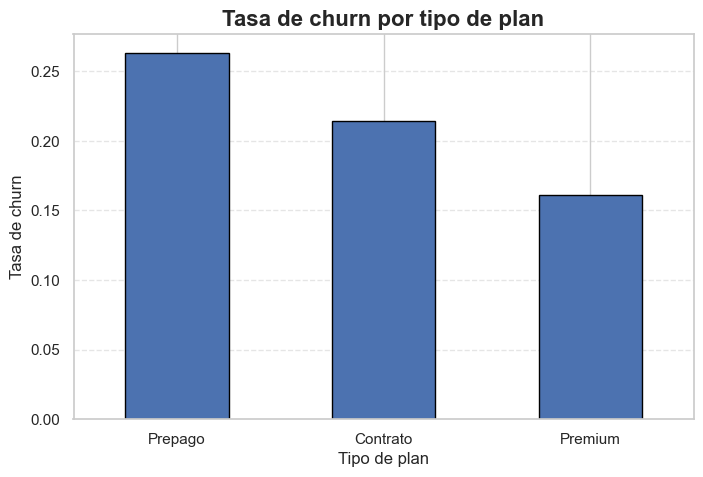

Estadístico Kruskal-Wallis: 116.667
P-valor: 0.000000


In [59]:
churn_plan = (
    df_modelo_final.groupby('tipo_plan')['churn']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

churn_plan.plot(
    kind='bar',
    edgecolor='black'
)

plt.title(
    'Tasa de churn por tipo de plan',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel('Tasa de churn')
plt.xlabel('Tipo de plan')

plt.xticks(rotation=0)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.show()

kw_h1 = stats.kruskal(
    *[
        group['churn'].values
        for name, group in df_modelo_final.groupby('tipo_plan')
    ]
)

print(f'Estadístico Kruskal-Wallis: {kw_h1.statistic:.3f}')
print(f'P-valor: {kw_h1.pvalue:.6f}')


El análisis bivariado muestra diferencias significativas en la tasa de churn según el tipo de plan contratado. Los clientes con planes prepago presentan la mayor tasa de abandono, mientras que los clientes premium muestran los niveles más bajos de churn. El test de Kruskal-Wallis confirma que estas diferencias son estadísticamente significativas (p < 0.001).

In [60]:
df_modelo_final.groupby(
    'tipo_zona'
)['churn'].mean().sort_values(
    ascending=False
)

tipo_zona
rural            0.33
suburbana        0.21
urbana_premium   0.14
Name: churn, dtype: float64

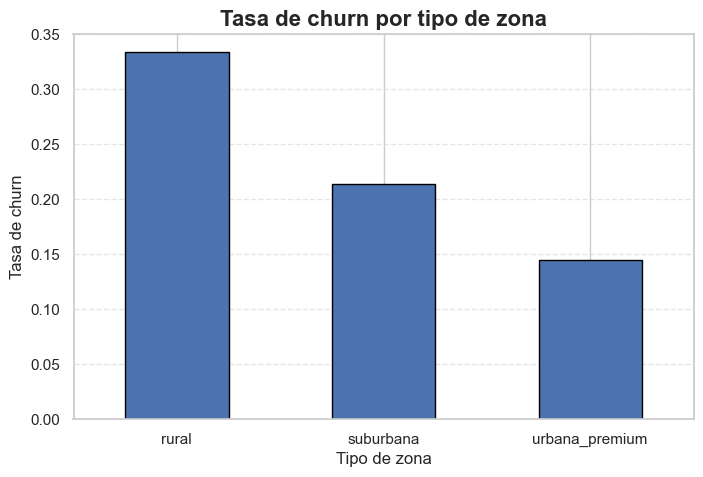

Estadístico Kruskal-Wallis: 251.216
P-valor: 0.000000


In [61]:
churn_zona = (
    df_modelo_final.groupby('tipo_zona')['churn']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

churn_zona.plot(
    kind='bar',
    edgecolor='black'
)

plt.title(
    'Tasa de churn por tipo de zona',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel('Tasa de churn')
plt.xlabel('Tipo de zona')

plt.xticks(rotation=0)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.show()

kw_h2 = stats.kruskal(
    *[
        group['churn'].values
        for name, group in df_modelo_final.groupby('tipo_zona')
    ]
)

print(f'Estadístico Kruskal-Wallis: {kw_h2.statistic:.3f}')
print(f'P-valor: {kw_h2.pvalue:.6f}')

El análisis bivariado evidencia diferencias significativas en la tasa de churn según el tipo de zona geográfica. Los clientes ubicados en zonas rurales presentan las mayores tasas de abandono, mientras que las zonas urbanas premium muestran los niveles más bajos de churn. Estos resultados podrían estar relacionados con diferencias en calidad de red, cobertura y experiencia de servicio entre regiones geográficas.

In [62]:
df_modelo_final.groupby(
    'region'
)['churn'].mean().sort_values(
    ascending=False
)

region
Centro   0.26
Norte    0.20
Sur      0.20
Oeste    0.19
Este     0.19
Name: churn, dtype: float64

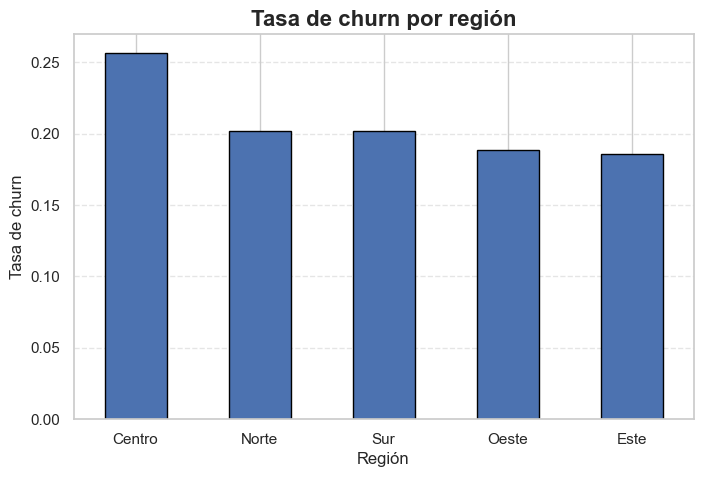

Estadístico Kruskal-Wallis: 29.381
P-valor: 0.000007


In [63]:
churn_region = (
    df_modelo_final.groupby('region')['churn']
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

churn_region.plot(
    kind='bar',
    edgecolor='black'
)

plt.title(
    'Tasa de churn por región',
    fontsize=16,
    fontweight='bold'
)

plt.ylabel('Tasa de churn')
plt.xlabel('Región')

plt.xticks(rotation=0)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.show()

kw_h3 = stats.kruskal(
    *[
        group['churn'].values
        for name, group in df_modelo_final.groupby('region')
    ]
)

print(f'Estadístico Kruskal-Wallis: {kw_h3.statistic:.3f}')
print(f'P-valor: {kw_h3.pvalue:.6f}')

Aunque se observan diferencias estadísticamente significativas en la tasa de churn entre regiones, el efecto visual parece más moderado en comparación con otras variables como el tipo de zona o el tipo de plan. La región Centro presenta la mayor tasa de abandono, mientras que el resto de regiones mantienen valores relativamente similares.

<Figure size 800x500 with 0 Axes>

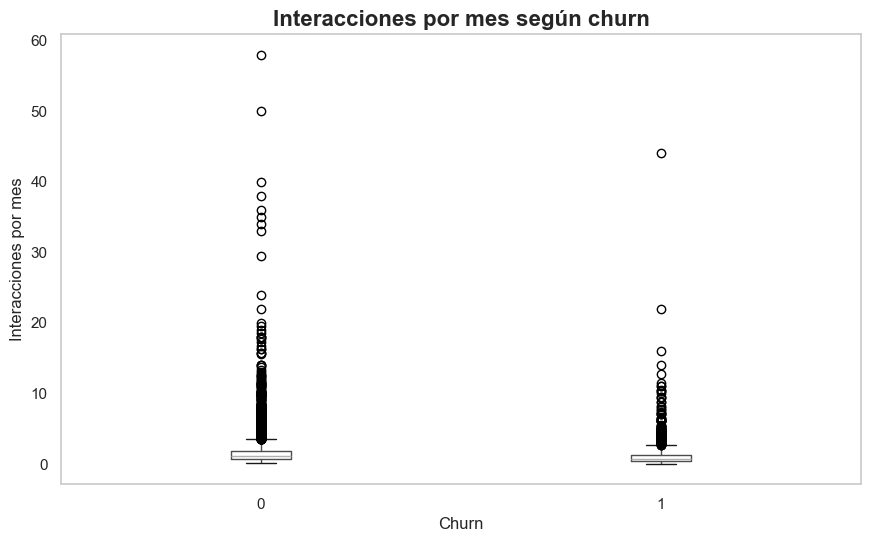

,count,mean,median,std
churn,,,,
0,7879,1.56,1.04,2.11
1,1976,1.12,0.67,1.78


Estadístico Mann-Whitney U: 10203224.500
P-valor: 0.000000


In [64]:
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# =========================
# Boxplot
# =========================

plt.figure(figsize=(8,5))

df_modelo_final.boxplot(
    column='interacciones_por_mes',
    by='churn',
    grid=False
)

plt.title(
    'Interacciones por mes según churn',
    fontsize=16,
    fontweight='bold'
)

plt.suptitle('')

plt.xlabel('Churn')
plt.ylabel('Interacciones por mes')

plt.show()

# =========================
# Estadísticos descriptivos
# =========================

summary_h4 = df_modelo_final.groupby(
    'churn'
)['interacciones_por_mes'].agg([
    'count',
    'mean',
    'median',
    'std'
])

display(summary_h4)

# =========================
# Test Mann-Whitney U
# =========================

grupo_0 = df_modelo_final[
    df_modelo_final['churn'] == 0
]['interacciones_por_mes']

grupo_1 = df_modelo_final[
    df_modelo_final['churn'] == 1
]['interacciones_por_mes']

mw_h4 = mannwhitneyu(
    grupo_0,
    grupo_1,
    alternative='two-sided'
)

print(f'Estadístico Mann-Whitney U: {mw_h4.statistic:.3f}')
print(f'P-valor: {mw_h4.pvalue:.6f}')

Contrariamente a la hipótesis inicial, los clientes que realizaron churn presentan, en promedio, un menor número de interacciones mensuales con soporte. Esto podría explicarse porque algunos clientes abandonan el servicio sin realizar contactos frecuentes con atención al cliente, o porque los clientes con mayor permanencia acumulan históricamente una mayor intensidad de uso del soporte

| Hipótesis | Resultado  | Evidencia                           |
| --------- | ---------- | ----------------------------------- |
| H1        | No apoyada | churners tienen menos interacciones |
| H2        | Apoyada    | diferencias claras por tipo_zona    |
| H3        | Apoyada    | rural presenta mayor churn          |
| H4        | Apoyada    | prepago tiene mayor churn           |


## MODELADO

### SELECCIÓN VARIABLES

In [65]:
### SELECCIÓN VARIABLES

In [66]:
numericas = [
    'edad',
    'num_lineas',
    'ingreso_estimado',
    'antiguedad_meses',
    'num_interacciones_total',
    'duracion_media',
    'pct_resuelto',
    'satisfaccion_media',
    'interacciones_por_mes'
]

In [67]:
categoricas = [
    'tipo_plan',
    'tipo_zona',
    'region',
    'sexo',
    'estado_civil',
    'tipo_dispositivo'
]

In [68]:
target = 'churn'

In [69]:
X = df_modelo_final[
    numericas + categoricas
]

y = df_modelo_final[target]

### Train test split

In [70]:
#   Usamos stratify = y porque el churn está desbalanceado  y así mantenemos la mismma proporción de churn en train y en test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [71]:

preprocessor = ColumnTransformer([
    (
        'num',
        StandardScaler(),
        numericas
    ),
    (
        'cat',
        OneHotEncoder(
            drop='first',
            handle_unknown='ignore'
        ),
        categoricas
    )
])

In [72]:
modelo = Pipeline([
    ('preprocessing', preprocessor),
    (
        'classifier',
        LogisticRegression(
            max_iter=1000,
            class_weight='balanced'
        )
    )
])

In [73]:
modelo.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [74]:
y_pred = modelo.predict(X_test)

In [75]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.94      0.88      0.91      1576
           1       0.61      0.77      0.69       395

    accuracy                           0.86      1971
   macro avg       0.78      0.83      0.80      1971
weighted avg       0.87      0.86      0.86      1971



El modelo benchmark basado en regresión logística mostró una capacidad razonable para detectar clientes con riesgo de churn. El recall de la clase churn alcanzó aproximadamente el 77%, indicando que el modelo consigue identificar una parte importante de los clientes que abandonan el servicio. Además, el F1-score obtenido sugiere un equilibrio aceptable entre precisión (61%)y capacidad de detección en esta primera iteración.

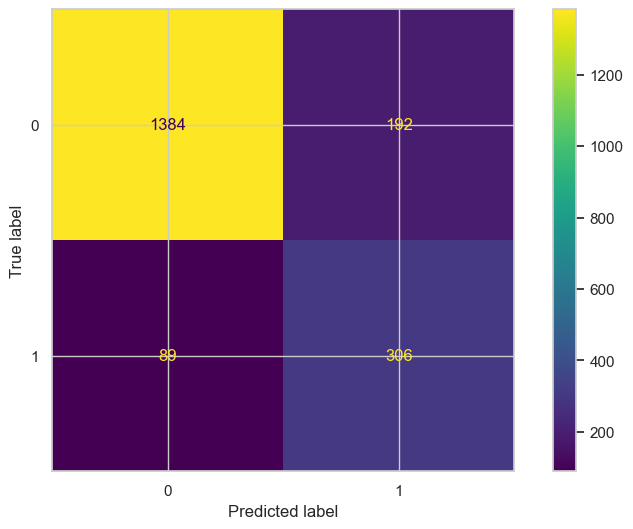

In [76]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [77]:
y_prob = modelo.predict_proba(X_test)[:,1]

roc_auc_score(
    y_test,
    y_prob
)

0.8994200989526442

El modelo benchmark obtuvo un ROC-AUC cercano a 0.90, indicando una buena capacidad para distinguir entre clientes con y sin riesgo de churn. Además, el recall de la clase churn fue elevado, permitiendo identificar aproximadamente el 77% de los clientes que abandonan el servicio.

,variable,coeficiente,abs_coef
12,tipo_zona_urbana_premium,-4.81,4.81
11,tipo_zona_suburbana,-2.74,2.74
4,num_interacciones_total,-2.54,2.54
10,tipo_plan_Prepago,1.13,1.13
21,estado_civil_Desconocido,-0.87,0.87
14,region_Norte,0.42,0.42
19,sexo_M,0.38,0.38
17,sexo_Desconocido,0.37,0.37
18,sexo_F,0.33,0.33
25,tipo_dispositivo_Gama baja,0.29,0.29


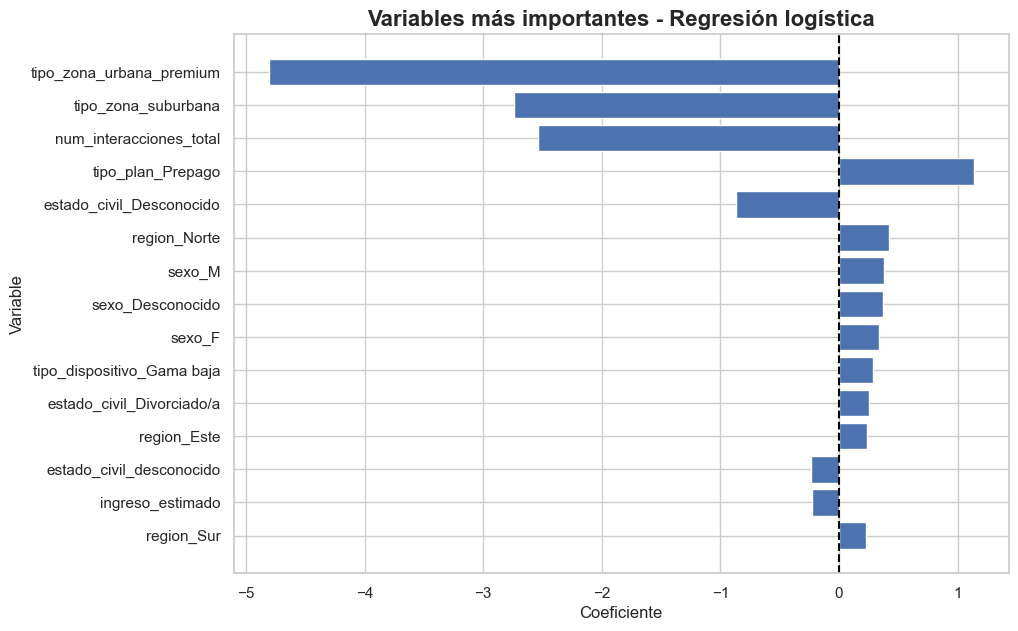

In [78]:
# Sacar nombres columnas
# =========================

feature_names = (
    numericas
    +
    list(
        modelo.named_steps[
            'preprocessing'
        ]
        .named_transformers_['cat']
        .get_feature_names_out(categoricas)
    )
)

# =========================
# Sacar coeficientes
# =========================

coeficientes = (
    modelo.named_steps['classifier']
    .coef_[0]
)

# =========================
# Crear dataframe
# =========================

coef_df = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': coeficientes
})

# =========================
# Ordenar por importancia
# =========================

coef_df['abs_coef'] = np.abs(
    coef_df['coeficiente']
)

coef_df = coef_df.sort_values(
    'abs_coef',
    ascending=False
)

display(coef_df.head(15))

# =========================
# Gráfico
# =========================

top_coef = coef_df.head(15)

plt.figure(figsize=(10,7))

plt.barh(
    top_coef['variable'],
    top_coef['coeficiente']
)

plt.axvline(
    x=0,
    color='black',
    linestyle='--'
)

plt.title(
    'Variables más importantes - Regresión logística',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Coeficiente')
plt.ylabel('Variable')

plt.gca().invert_yaxis()

plt.show()

In [79]:
y_prob = modelo.predict_proba(X_test)[:,1]

In [80]:
threshold = 0.7

In [81]:
y_pred_new = (
    y_prob >= threshold
).astype(int)

In [82]:

print(
    classification_report(
        y_test,
        y_pred_new
    )
)

print(
    confusion_matrix(
        y_test,
        y_pred_new
    )
)

              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1576
           1       0.82      0.67      0.74       395

    accuracy                           0.90      1971
   macro avg       0.87      0.82      0.84      1971
weighted avg       0.90      0.90      0.90      1971

[[1517   59]
 [ 129  266]]


#  2º ITERACIÓN


Añadimos facturación ID para poder observar el comportamiento económico y temporal de los clientes

In [83]:
df_facturacion = pd.read_csv(
    r"C:\Users\ancar\Documents\Prácticas\UCV-Churn\data\raw\facturacion_mensual.csv"
)

In [84]:
df_facturacion.info()

<class 'pandas.DataFrame'>
RangeIndex: 326816 entries, 0 to 326815
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   cliente_id             326816 non-null  str    
 1   fecha                  326816 non-null  str    
 2   zona_id                326816 non-null  str    
 3   tipo_plan              317000 non-null  str    
 4   num_lineas             326816 non-null  int64  
 5   cargo_base             326816 non-null  float64
 6   consumo_extra          326816 non-null  float64
 7   descuento_aplicado     326816 non-null  float64
 8   importe_total          317017 non-null  float64
 9   dias_retraso_pago      326816 non-null  int64  
 10  impago_flag            326816 non-null  int64  
 11  variacion_consumo_pct  326816 non-null  float64
 12  stress_calidad_lag     326816 non-null  float64
 13  incidencia_masiva_lag  326816 non-null  int64  
dtypes: float64(6), int64(4), str(4)
memory usage: 3

In [85]:
df_facturacion.isnull().sum()

cliente_id                  0
fecha                       0
zona_id                     0
tipo_plan                9816
num_lineas                  0
cargo_base                  0
consumo_extra               0
descuento_aplicado          0
importe_total            9799
dias_retraso_pago           0
impago_flag                 0
variacion_consumo_pct       0
stress_calidad_lag          0
incidencia_masiva_lag       0
dtype: int64

Solo eliminamos el nulo de importe total ya que el tipo de plan ya lo tenemos en el modelo_final como variable y limpio

In [86]:
df_facturacion['importe_total'] = (
    df_facturacion['importe_total']
    .fillna(
        df_facturacion['importe_total'].median()
    )
)

In [87]:
df_facturacion.duplicated().sum()

np.int64(4829)

In [88]:
df_facturacion[
    df_facturacion.duplicated()
].head()

,cliente_id,fecha,zona_id,tipo_plan,num_lineas,cargo_base,consumo_extra,descuento_aplicado,importe_total,dias_retraso_pago,impago_flag,variacion_consumo_pct,stress_calidad_lag,incidencia_masiva_lag
321987,C007415,2023-10-01,Z21,Prepago,2,46.63,2.55,0.00,49.18,22,1,2.55,0.78,0
321988,C006590,2023-09-01,Z16,Contrato,4,144.40,0.41,0.00,144.81,0,0,-0.95,0.40,0
321989,C006021,2023-09-01,Z30,Premium,2,124.20,0.00,0.00,124.20,0,0,-1.00,0.53,0
321990,C008268,2023-02-01,Z06,Premium,1,77.29,4.29,0.00,81.59,0,0,-0.43,0.71,0
321991,C007927,2023-03-01,Z06,Prepago,1,22.71,7.99,0.00,30.70,0,0,0.96,0.68,0


In [89]:
df_facturacion[
    df_facturacion.duplicated(
        subset=['cliente_id', 'fecha']
    )
].head()

,cliente_id,fecha,zona_id,tipo_plan,num_lineas,cargo_base,consumo_extra,descuento_aplicado,importe_total,dias_retraso_pago,impago_flag,variacion_consumo_pct,stress_calidad_lag,incidencia_masiva_lag
321987,C007415,2023-10-01,Z21,Prepago,2,46.63,2.55,0.00,49.18,22,1,2.55,0.78,0
321988,C006590,2023-09-01,Z16,Contrato,4,144.40,0.41,0.00,144.81,0,0,-0.95,0.40,0
321989,C006021,2023-09-01,Z30,Premium,2,124.20,0.00,0.00,124.20,0,0,-1.00,0.53,0
321990,C008268,2023-02-01,Z06,Premium,1,77.29,4.29,0.00,81.59,0,0,-0.43,0.71,0
321991,C007927,2023-03-01,Z06,Prepago,1,22.71,7.99,0.00,30.70,0,0,0.96,0.68,0


In [90]:
df_facturacion = df_facturacion.drop_duplicates()

In [91]:
df_facturacion.duplicated().sum()

np.int64(0)

Se identificaron registros duplicados completos en la tabla de facturación mensual. Al tratarse de duplicados exactos en todas las variables, se procedió a su eliminación para evitar sesgos en el análisis y en la construcción de variables agregadas.

In [92]:
facturacion_agg = df_facturacion.groupby(
    'cliente_id'
).agg({

    'importe_total': 'mean',
    'dias_retraso_pago': 'mean',
    'impago_flag': ['sum', 'mean'],
    'variacion_consumo_pct': 'mean',
    'stress_calidad_lag': 'mean',
    'incidencia_masiva_lag': 'sum'

}).reset_index()

In [93]:
facturacion_agg.columns = [
    'cliente_id',
    'importe_medio',
    'retraso_pago_medio',
    'num_impagos',
    'pct_impagos',
    'variacion_consumo_media',
    'stress_red_medio',
    'num_incidencias_masivas'
]

In [94]:
df_modelo_v2 = df_modelo_final.merge(
    facturacion_agg,
    on='cliente_id',
    how='left'
)

In [95]:
df_modelo_v2.isnull().sum()

cliente_id                 0
churn                      0
zona_id                    0
region                     0
tipo_zona                  0
poblacion_zona             0
edad                       0
sexo                       0
estado_civil               0
num_lineas                 0
tipo_plan                  0
tipo_dispositivo           0
ingreso_estimado           0
antiguedad_meses           0
descuento_activo           0
num_interacciones_total    0
duracion_media             0
pct_resuelto               0
satisfaccion_media         0
interacciones_por_mes      0
importe_medio              0
retraso_pago_medio         0
num_impagos                0
pct_impagos                0
variacion_consumo_media    0
stress_red_medio           0
num_incidencias_masivas    0
dtype: int64

In [96]:
numericas_v2 = [
    'edad',
    'num_lineas',
    'ingreso_estimado',
    'antiguedad_meses',
    'num_interacciones_total',
    'duracion_media',
    'pct_resuelto',
    'satisfaccion_media',
    'interacciones_por_mes',

    # NUEVAS
    'importe_medio',
    'retraso_pago_medio',
    'num_impagos',
    'pct_impagos',
    'variacion_consumo_media',
    'stress_red_medio',
    'num_incidencias_masivas'
]

Solo eliminamos el nulo de importe total ya que el tipo de plan ya lo tenemos en el modelo_final como variable y limpio

In [97]:
categoricas_v2 = [
    'tipo_plan',
    'tipo_zona',
    'region',
    'sexo',
    'estado_civil',
    'tipo_dispositivo'
]

In [98]:
X = df_modelo_v2[
    numericas_v2 + categoricas_v2
]

y = df_modelo_v2['churn']

In [99]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [100]:

preprocessor = ColumnTransformer([
    (
        'num',
        StandardScaler(),
        numericas_v2
    ),
    (
        'cat',
        OneHotEncoder(
            drop='first',
            handle_unknown='ignore'
        ),
        categoricas_v2
    )
])

In [101]:

modelo_v2 = Pipeline([
    ('preprocessing', preprocessor),
    (
        'classifier',
        LogisticRegression(
            max_iter=1000,
            class_weight='balanced'
        )
    )
])

In [102]:
modelo_v2.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [103]:
y_pred = modelo_v2.predict(X_test)

In [104]:

print(
    classification_report(
        y_test,
        y_pred
    )
)

y_prob = modelo_v2.predict_proba(X_test)[:,1]

print(
    'ROC-AUC:',
    roc_auc_score(
        y_test,
        y_prob
    )
)

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1576
           1       0.96      0.91      0.94       395

    accuracy                           0.97      1971
   macro avg       0.97      0.95      0.96      1971
weighted avg       0.97      0.97      0.97      1971

ROC-AUC: 0.98161665488659


,variable,coeficiente,abs_coef
12,pct_impagos,16.53,16.53
11,num_impagos,-11.16,11.16
21,region_Norte,2.29,2.29
4,num_interacciones_total,-2.03,2.03
14,stress_red_medio,1.98,1.98
19,tipo_zona_urbana_premium,1.29,1.29
17,tipo_plan_Prepago,1.08,1.08
18,tipo_zona_suburbana,0.75,0.75
15,num_incidencias_masivas,-0.71,0.71
26,sexo_M,0.52,0.52


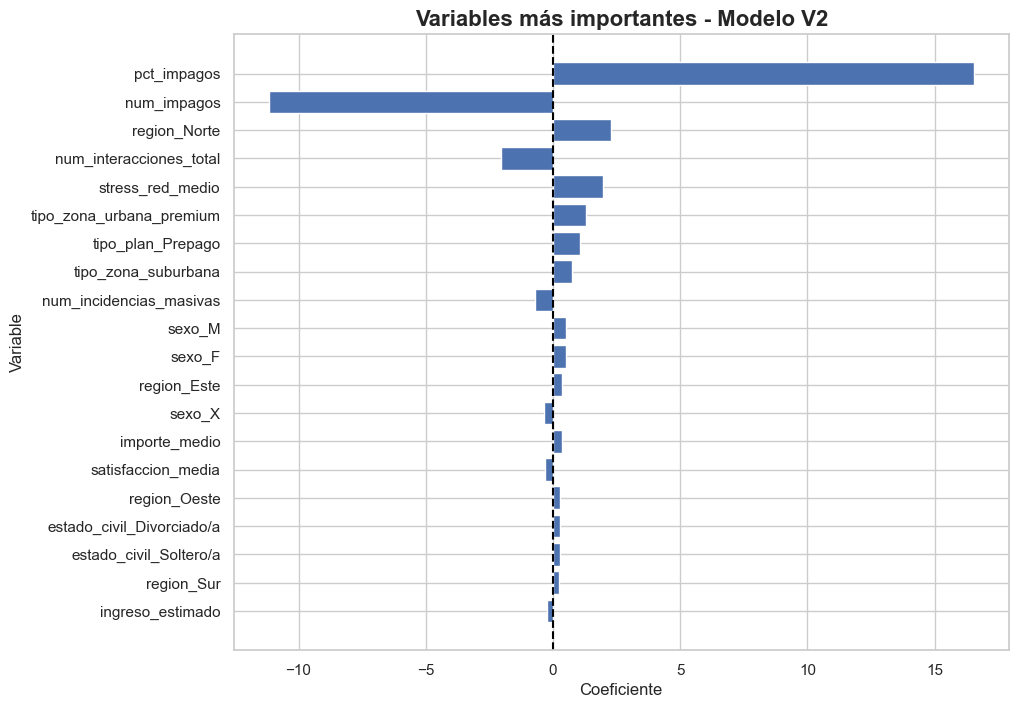

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Nombres columnas
# =========================

feature_names = (
    numericas_v2
    +
    list(
        modelo_v2.named_steps[
            'preprocessing'
        ]
        .named_transformers_['cat']
        .get_feature_names_out(categoricas_v2)
    )
)

# =========================
# Coeficientes
# =========================

coeficientes = (
    modelo_v2.named_steps[
        'classifier'
    ].coef_[0]
)

# =========================
# Dataframe
# =========================

coef_df = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': coeficientes
})

coef_df['abs_coef'] = np.abs(
    coef_df['coeficiente']
)

coef_df = coef_df.sort_values(
    'abs_coef',
    ascending=False
)

display(coef_df.head(20))

# =========================
# Gráfico
# =========================

top_coef = coef_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top_coef['variable'],
    top_coef['coeficiente']
)

plt.axvline(
    x=0,
    color='black',
    linestyle='--'
)

plt.title(
    'Variables más importantes - Modelo V2',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Coeficiente')
plt.ylabel('Variable')

plt.gca().invert_yaxis()

plt.show()

vamos a quitar pct_impagos ya que domina todo el modelo y además puede que esté ocasionado data leakage

In [106]:
numericas_v3 = [
    'edad',
    'num_lineas',
    'ingreso_estimado',
    'antiguedad_meses',
    'num_interacciones_total',
    'duracion_media',
    'pct_resuelto',
    'satisfaccion_media',
    'interacciones_por_mes',

    # NUEVAS
    'importe_medio',
    'retraso_pago_medio',
    'num_impagos',
    'variacion_consumo_media',
    'stress_red_medio',
    'num_incidencias_masivas'
]

In [107]:
categoricas_v3 = [
    'tipo_plan',
    'tipo_zona',
    'region',
    'sexo',
    'estado_civil',
    'tipo_dispositivo'
]

In [108]:
X = df_modelo_v2[
    numericas_v3 + categoricas_v3
]

y = df_modelo_v2['churn']

In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [110]:

preprocessor = ColumnTransformer([
    (
        'num',
        StandardScaler(),
        numericas_v3
    ),
    (
        'cat',
        OneHotEncoder(
            drop='first',
            handle_unknown='ignore'
        ),
        categoricas_v3
    )
])

In [111]:

modelo_v3 = Pipeline([
    ('preprocessing', preprocessor),
    (
        'classifier',
        LogisticRegression(
            max_iter=1000,
            class_weight='balanced'
        )
    )
])

In [112]:
modelo_v3.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [113]:
y_pred = modelo_v3.predict(X_test)

In [114]:

print(
    classification_report(
        y_test,
        y_pred
    )
)

y_prob = modelo_v3.predict_proba(X_test)[:,1]

print(
    'ROC-AUC:',
    roc_auc_score(
        y_test,
        y_prob
    )
)

              precision    recall  f1-score   support

           0       0.96      0.91      0.93      1576
           1       0.70      0.84      0.77       395

    accuracy                           0.90      1971
   macro avg       0.83      0.88      0.85      1971
weighted avg       0.91      0.90      0.90      1971

ROC-AUC: 0.9381047998457881


,variable,coeficiente,abs_coef
18,tipo_zona_urbana_premium,4.81,4.81
13,stress_red_medio,3.62,3.62
20,region_Norte,3.15,3.15
4,num_interacciones_total,-2.86,2.86
17,tipo_zona_suburbana,2.77,2.77
16,tipo_plan_Prepago,1.45,1.45
14,num_incidencias_masivas,-1.06,1.06
10,retraso_pago_medio,0.62,0.62
27,estado_civil_Desconocido,-0.56,0.56
7,satisfaccion_media,-0.49,0.49


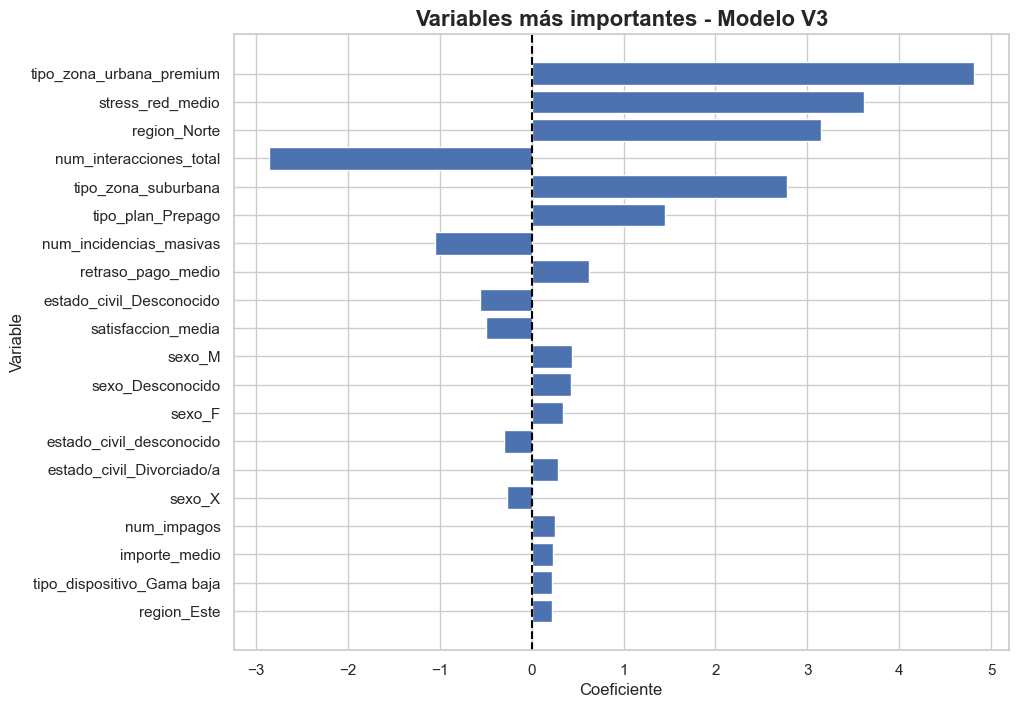

In [115]:

# =========================
# Nombres columnas
# =========================

feature_names = (
    numericas_v3
    +
    list(
        modelo_v3.named_steps[
            'preprocessing'
        ]
        .named_transformers_['cat']
        .get_feature_names_out(categoricas_v3)
    )
)

# =========================
# Coeficientes
# =========================

coeficientes = (
    modelo_v3.named_steps[
        'classifier'
    ].coef_[0]
)

# =========================
# Dataframe
# =========================

coef_df = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': coeficientes
})

coef_df['abs_coef'] = np.abs(
    coef_df['coeficiente']
)

coef_df = coef_df.sort_values(
    'abs_coef',
    ascending=False
)

display(coef_df.head(20))

# =========================
# Gráfico
# =========================

top_coef = coef_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top_coef['variable'],
    top_coef['coeficiente']
)

plt.axvline(
    x=0,
    color='black',
    linestyle='--'
)

plt.title(
    'Variables más importantes - Modelo V3',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Coeficiente')
plt.ylabel('Variable')

plt.gca().invert_yaxis()

plt.show()

Solo eliminamos el nulo de importe total ya que el tipo de plan ya lo tenemos en el modelo_final como variable y limpio

# ITERACIÓN 3

Vamos a pasar a usar cliente-mes y añadir el churn en los próximos tres meses

In [116]:
df_facturacion_original = pd.read_csv(
    r"C:\Users\ancar\Documents\Prácticas\UCV-Churn\data\raw\facturacion_mensual.csv"
)

print(df_facturacion_original.shape)

(326816, 14)


In [117]:
df_facturacion = df_facturacion_original.copy()

print(df_facturacion.shape)

(326816, 14)


In [118]:
df_facturacion['fecha'].head(20)

0     2023-01-01
1     2023-02-01
2     2023-03-01
3     2023-04-01
4     2023-05-01
5     2023-06-01
6     2023-07-01
7     2023-08-01
8     2023-09-01
9     2023-10-01
10    2023-11-01
11    2023-12-01
12    2024-01-01
13    2024-02-01
14    2024-03-01
15    2024-04-01
16    2024-05-01
17    2024-06-01
18    2024-07-01
19    2024-08-01
Name: fecha, dtype: str

In [119]:
print(df_facturacion_original.shape)
print(df_facturacion.shape)

(326816, 14)
(326816, 14)


In [120]:
df_facturacion[
    df_facturacion['fecha'].str.contains('/')
]['fecha'].head(20)

47      01/12/2023
114     01/12/2023
311     01/05/2025
331     01/01/2024
394     01/04/2023
439     01/01/2024
553     01/07/2024
746     01/08/2025
1170    01/01/2024
1200    01/07/2023
1214    01/09/2024
1249    01/08/2024
1278    01/01/2024
1288    01/11/2024
1359    01/10/2024
1397    01/12/2024
1510    01/03/2023
1675    01/12/2024
1684    01/09/2025
1700    01/01/2024
Name: fecha, dtype: str

In [121]:

#Función para convertir fechas en diferentes formatos a datetime
def convertir_fecha(x):
    x = str(x)

    if '-' in x:
        return pd.to_datetime(x, format='%Y-%m-%d')

    elif '/' in x:
        return pd.to_datetime(x, format='%d/%m/%Y')

    return pd.NaT

df_facturacion['fecha'] = df_facturacion['fecha'].apply(convertir_fecha)

In [122]:
df_facturacion['fecha'].dtype

dtype('<M8[us]')

In [123]:
df_facturacion = df_facturacion.rename(
    columns={'fecha':'mes'}
)

In [124]:
df_facturacion[['cliente_id','mes']].head()

,cliente_id,mes
0,C000001,2023-01-01
1,C000001,2023-02-01
2,C000001,2023-03-01
3,C000001,2023-04-01
4,C000001,2023-05-01


In [125]:
print(df_churn.columns.tolist())

['cliente_id', 'fecha', 'churn']


In [126]:
df_churn['fecha'] = pd.to_datetime(df_churn['fecha'])

df_churn = df_churn.rename(
    columns={'fecha': 'mes'}
)

In [127]:
print(df_churn['mes'].dtype)
print(df_facturacion['mes'].dtype)

datetime64[us]
datetime64[us]


In [128]:
df_modelo_temp = df_churn.merge(
    df_facturacion,
    on=['cliente_id', 'mes'],
    how='left'
)

print(df_modelo_temp.shape)

(326816, 15)


In [129]:
df_modelo_temp.isnull().sum().sort_values(ascending=False).head(20)

tipo_plan                9816
importe_total            9799
mes                         0
churn                       0
zona_id                     0
num_lineas                  0
cliente_id                  0
cargo_base                  0
consumo_extra               0
descuento_aplicado          0
dias_retraso_pago           0
impago_flag                 0
variacion_consumo_pct       0
stress_calidad_lag          0
incidencia_masiva_lag       0
dtype: int64

In [130]:
df_facturacion[
    df_facturacion['cliente_id'] == 'C000002'
][['cliente_id','mes']].head(20)

,cliente_id,mes
36,C000002,2023-01-01
37,C000002,2023-02-01
38,C000002,2023-03-01
39,C000002,2023-04-01
40,C000002,2023-05-01
41,C000002,2023-06-01
42,C000002,2023-07-01
43,C000002,2023-08-01
44,C000002,2023-09-01
45,C000002,2023-10-01


In [131]:
df_facturacion['tipo_plan'] = (
    df_facturacion['tipo_plan']
    .fillna('Desconocido')
)

df_facturacion['importe_total'] = (
    df_facturacion['importe_total']
    .fillna(df_facturacion['importe_total'].median())
)

In [132]:
soporte_agg = (
    df_soporte
    .groupby(['cliente_id', 'mes'])
    .agg(
        num_interacciones=('interaccion_id', 'count'),
        duracion_media=('duracion_min', 'mean'),
        pct_resuelto=('resuelto', 'mean'),
        satisfaccion_media=('satisfaccion_post', 'mean')
    )
    .reset_index()
)

In [133]:
soporte_agg['mes'] = pd.to_datetime(
    soporte_agg['mes']
)
df_modelo_temp = df_churn.merge(
    df_facturacion,
    on=['cliente_id','mes'],
    how='left'
)

df_modelo_temp = df_modelo_temp.merge(
    soporte_agg,
    on=['cliente_id','mes'],
    how='left'
)

In [134]:
df_modelo_temp.isnull().sum().sort_values(ascending=False).head(20)

pct_resuelto             145030
duracion_media           145030
num_interacciones        145030
satisfaccion_media       145030
churn                         0
cliente_id                    0
mes                           0
zona_id                       0
tipo_plan                     0
num_lineas                    0
cargo_base                    0
dias_retraso_pago             0
importe_total                 0
descuento_aplicado            0
consumo_extra                 0
incidencia_masiva_lag         0
stress_calidad_lag            0
variacion_consumo_pct         0
impago_flag                   0
dtype: int64

In [135]:
cols_soporte = [
    'num_interacciones',
    'duracion_media',
    'pct_resuelto',
    'satisfaccion_media'
]

df_modelo_temp[cols_soporte] = (
    df_modelo_temp[cols_soporte]
    .fillna(0)
)

In [136]:
df_modelo_temp.isnull().sum().sum()

np.int64(0)

In [137]:
df_modelo_temp = (
    df_modelo_temp
    .sort_values(['cliente_id', 'mes'])
)

df_modelo_temp['churn_3m'] = (
    df_modelo_temp
    .groupby('cliente_id')['churn']
    .transform(
        lambda x:
        (
            x.shift(-1).fillna(0)
            + x.shift(-2).fillna(0)
            + x.shift(-3).fillna(0)
        ) > 0
    )
    .astype(int)
)

In [138]:
df_modelo_temp['churn_3m'].value_counts()

churn_3m
0    320980
1      5836
Name: count, dtype: int64

In [139]:
ejemplo = (
    df_modelo_temp[df_modelo_temp['churn'] == 1]
    ['cliente_id']
    .iloc[0]
)

df_modelo_temp[
    df_modelo_temp['cliente_id'] == ejemplo
][['cliente_id','mes','churn','churn_3m']].tail(10)

,cliente_id,mes,churn,churn_3m
96,C000003,2024-10-01,0,0
97,C000003,2024-11-01,0,0
98,C000003,2024-12-01,0,0
99,C000003,2025-01-01,0,0
100,C000003,2025-02-01,0,0
101,C000003,2025-03-01,0,0
102,C000003,2025-04-01,0,1
103,C000003,2025-05-01,0,1
104,C000003,2025-06-01,0,1
105,C000003,2025-07-01,1,0


In [140]:
columnas_excluir = [
    'cliente_id',
    'mes',
    'churn',
    'churn_3m'
]

In [141]:
X = df_modelo_temp.drop(columns=columnas_excluir)

y = df_modelo_temp['churn_3m']

In [142]:
fecha_corte = '2025-07-01'

train = df_modelo_temp[
    df_modelo_temp['mes'] < fecha_corte
]

test = df_modelo_temp[
    df_modelo_temp['mes'] >= fecha_corte
]

In [143]:
X_train = train.drop(
    columns=['cliente_id','mes','churn','churn_3m']
)

y_train = train['churn_3m']

X_test = test.drop(
    columns=['cliente_id','mes','churn','churn_3m']
)

y_test = test['churn_3m']

In [144]:
cat_cols = X_train.select_dtypes(
    include=['object']
).columns.tolist()

num_cols = X_train.select_dtypes(
    exclude=['object']
).columns.tolist()

print(cat_cols)
print(num_cols)

['zona_id', 'tipo_plan']
['num_lineas', 'cargo_base', 'consumo_extra', 'descuento_aplicado', 'importe_total', 'dias_retraso_pago', 'impago_flag', 'variacion_consumo_pct', 'stress_calidad_lag', 'incidencia_masiva_lag', 'num_interacciones', 'duracion_media', 'pct_resuelto', 'satisfaccion_media']


In [145]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessing = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [146]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ('preprocessing', preprocessing),
    (
        'modelo',
        LogisticRegression(
            max_iter=5000,
            class_weight='balanced',
            random_state=42
        )
    )
])

In [147]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [148]:
y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:,1]

In [149]:


print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob)
)

              precision    recall  f1-score   support

           0       0.99      0.73      0.84     49111
           1       0.02      0.50      0.04       496

    accuracy                           0.73     49607
   macro avg       0.51      0.61      0.44     49607
weighted avg       0.98      0.73      0.83     49607

[[35866 13245]
 [  249   247]]
ROC-AUC: 0.6637343417577429


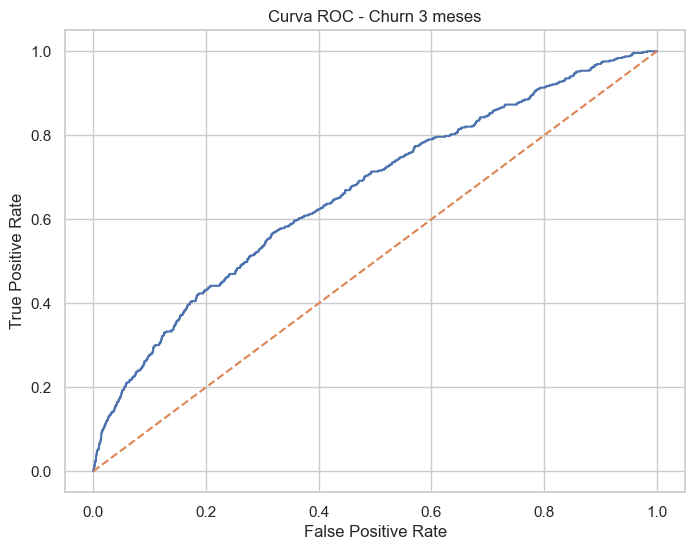

In [150]:
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Churn 3 meses")
plt.grid(True)
plt.show()

In [151]:
# ==========================================================
# NOMBRES DE VARIABLES
# ==========================================================

feature_names = (
    num_cols
    +
    list(
        pipeline.named_steps['preprocessing']
        .named_transformers_['cat']
        .get_feature_names_out(cat_cols)
    )
)

# ==========================================================
# COEFICIENTES
# ==========================================================

coeficientes = (
    pipeline.named_steps['modelo']
    .coef_[0]
)

importancia = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': coeficientes
})

importancia['abs_coef'] = (
    importancia['coeficiente']
    .abs()
)

importancia = (
    importancia
    .sort_values(
        'abs_coef',
        ascending=False
    )
)

importancia.head(20)

,variable,coeficiente,abs_coef
20,zona_id_Z07,0.44,0.44
31,zona_id_Z18,-0.42,0.42
39,zona_id_Z26,-0.41,0.41
14,zona_id_Z01,0.39,0.39
42,zona_id_Z29,-0.38,0.38
18,zona_id_Z05,-0.35,0.35
19,zona_id_Z06,0.31,0.31
32,zona_id_Z19,0.31,0.31
22,zona_id_Z09,-0.29,0.29
16,zona_id_Z03,0.29,0.29


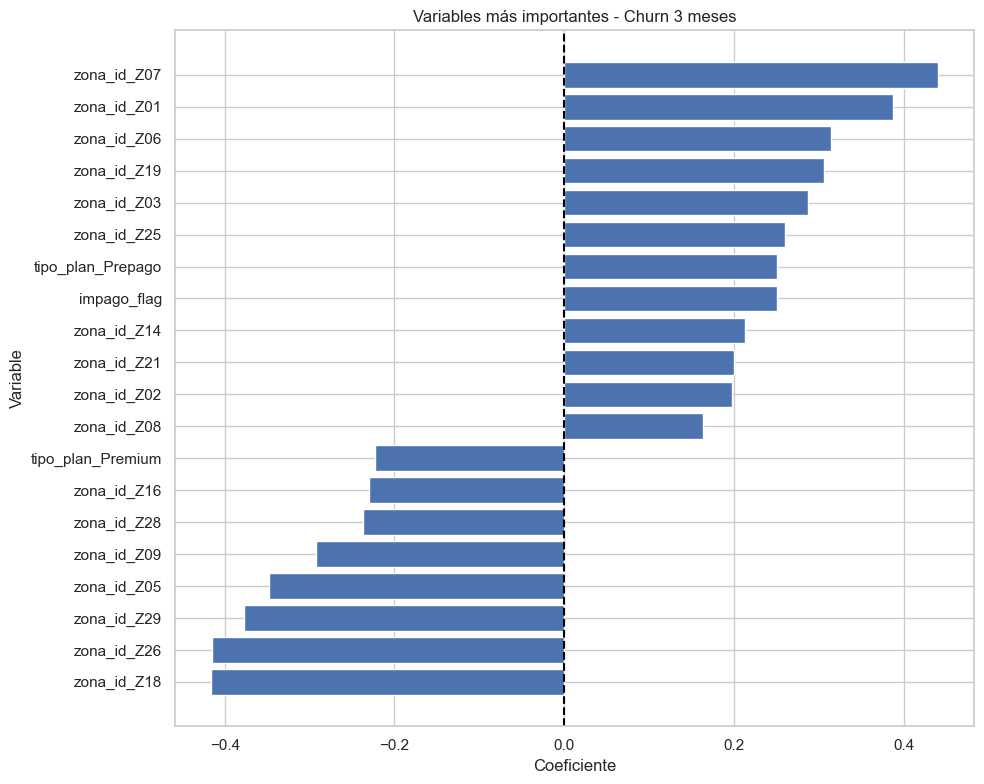

In [152]:

top_n = 20

top_vars = (
    importancia
    .head(top_n)
    .sort_values('coeficiente')
)

plt.figure(figsize=(10,8))

plt.barh(
    top_vars['variable'],
    top_vars['coeficiente']
)

plt.axvline(
    x=0,
    color='black',
    linestyle='--'
)

plt.title(
    'Variables más importantes - Churn 3 meses'
)

plt.xlabel('Coeficiente')
plt.ylabel('Variable')

plt.tight_layout()
plt.show()

In [153]:
print(X.columns.tolist())

['zona_id', 'tipo_plan', 'num_lineas', 'cargo_base', 'consumo_extra', 'descuento_aplicado', 'importe_total', 'dias_retraso_pago', 'impago_flag', 'variacion_consumo_pct', 'stress_calidad_lag', 'incidencia_masiva_lag', 'num_interacciones', 'duracion_media', 'pct_resuelto', 'satisfaccion_media']


### 4º ITERACIÓN

En esta iteración se añadirán variables acumuladas de los últimos 3 meses al modelo que tenemos-


In [154]:
df_modelo_temp = df_modelo_temp.sort_values(
    ['cliente_id','mes']
)

In [155]:
df_modelo_temp['importe_3m'] = (
    df_modelo_temp
    .groupby('cliente_id')['importe_total']
    .transform(
        lambda x: x.shift(1).rolling(3,min_periods=1).mean()
    )
)

In [156]:
df_modelo_temp['retraso_3m'] = (
    df_modelo_temp
    .groupby('cliente_id')['dias_retraso_pago']
    .transform(
        lambda x: x.shift(1).rolling(3,min_periods=1).mean()
    )
)

In [157]:
df_modelo_temp['impagos_3m'] = (
    df_modelo_temp
    .groupby('cliente_id')['impago_flag']
    .transform(
        lambda x: x.shift(1).rolling(3,min_periods=1).sum()
    )
)

In [158]:
df_modelo_temp['interacciones_3m'] = (
    df_modelo_temp
    .groupby('cliente_id')['num_interacciones']
    .transform(
        lambda x: x.shift(1).rolling(3,min_periods=1).sum()
    )
)

In [159]:
df_modelo_temp['satisfaccion_3m'] = (
    df_modelo_temp
    .groupby('cliente_id')['satisfaccion_media']
    .transform(
        lambda x: x.shift(1).rolling(3,min_periods=1).mean()
    )
)

In [160]:
features = [
'zona_id',
'tipo_plan',
'num_lineas',
'cargo_base',
'consumo_extra',
'descuento_aplicado',
'importe_total',
'dias_retraso_pago',
'impago_flag',
'variacion_consumo_pct',
'stress_calidad_lag',
'incidencia_masiva_lag',
'num_interacciones',
'duracion_media',
'pct_resuelto',
'satisfaccion_media',

'importe_3m',
'retraso_3m',
'impagos_3m',
'interacciones_3m',
'satisfaccion_3m'
]

In [161]:
df_modelo_temp.isna().sum().sort_values(ascending=False).head(20)

retraso_3m               10000
satisfaccion_3m          10000
interacciones_3m         10000
impagos_3m               10000
importe_3m               10000
mes                          0
churn                        0
zona_id                      0
cliente_id                   0
descuento_aplicado           0
consumo_extra                0
cargo_base                   0
num_lineas                   0
tipo_plan                    0
importe_total                0
impago_flag                  0
dias_retraso_pago            0
duracion_media               0
num_interacciones            0
incidencia_masiva_lag        0
dtype: int64

In [162]:
df_modelo_temp[['importe_3m',
                'retraso_3m',
                'impagos_3m',
                'interacciones_3m',
                'satisfaccion_3m']] = (
    df_modelo_temp[['importe_3m',
                    'retraso_3m',
                    'impagos_3m',
                    'interacciones_3m',
                    'satisfaccion_3m']]
    .fillna(0)
)

In [163]:
features = [
    'zona_id',
    'tipo_plan',
    'num_lineas',
    'cargo_base',
    'consumo_extra',
    'descuento_aplicado',
    'importe_total',
    'dias_retraso_pago',
    'impago_flag',
    'variacion_consumo_pct',
    'stress_calidad_lag',
    'incidencia_masiva_lag',
    'num_interacciones',
    'duracion_media',
    'pct_resuelto',
    'satisfaccion_media',

    'importe_3m',
    'retraso_3m',
    'impagos_3m',
    'interacciones_3m',
    'satisfaccion_3m'
]

X = df_modelo_temp[features]
y = df_modelo_temp['churn_3m']

In [164]:
# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# VARIABLES
# ==========================================================

cat_cols = X.select_dtypes(include=['object']).columns.tolist()

num_cols = [
    col for col in X.columns
    if col not in cat_cols
]

# ==========================================================
# PREPROCESAMIENTO
# ==========================================================

preprocessing = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# ==========================================================
# PIPELINE
# ==========================================================

pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

# ==========================================================
# ENTRENAMIENTO
# ==========================================================

pipeline.fit(X_train, y_train)

# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:,1]

# ==========================================================
# MÉTRICAS
# ==========================================================

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)

print(f"\nROC-AUC: {roc_auc:.4f}")

              precision    recall  f1-score   support

           0       0.99      0.65      0.78     64197
           1       0.03      0.55      0.05      1167

    accuracy                           0.65     65364
   macro avg       0.51      0.60      0.42     65364
weighted avg       0.97      0.65      0.77     65364

[[41629 22568]
 [  520   647]]

ROC-AUC: 0.6436


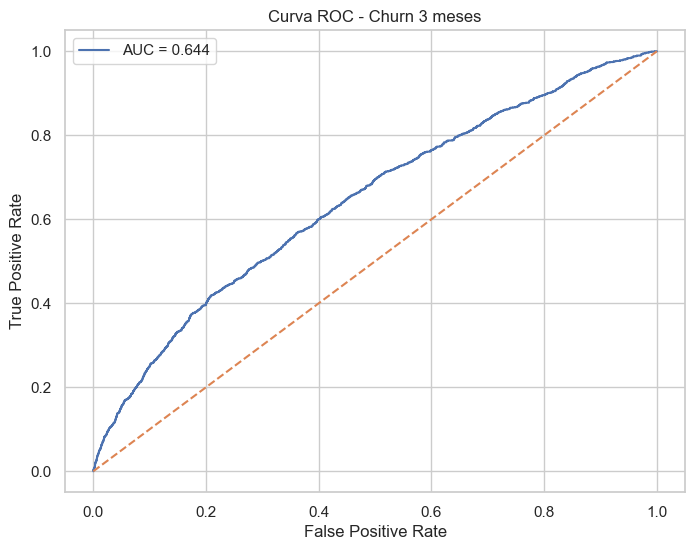

In [165]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Churn 3 meses')
plt.legend()
plt.grid(True)
plt.show()


In [166]:
feature_names = (
    pipeline.named_steps['preprocessing']
    .get_feature_names_out()
)

coeficientes = (
    pipeline.named_steps['model']
    .coef_[0]
)

importancia = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': coeficientes
})

importancia['abs_coef'] = importancia['coeficiente'].abs()

importancia = (
    importancia
    .sort_values('abs_coef', ascending=False)
)

print(importancia.head(30))

                      variable  coeficiente  abs_coef
36            cat__zona_id_Z18        -0.39      0.39
8      num__stress_calidad_lag         0.32      0.32
25            cat__zona_id_Z07         0.30      0.30
14             num__importe_3m        -0.29      0.29
42            cat__zona_id_Z24        -0.28      0.28
52      cat__tipo_plan_Prepago         0.28      0.28
51      cat__tipo_plan_Premium        -0.26      0.26
6             num__impago_flag         0.25      0.25
44            cat__zona_id_Z26        -0.24      0.24
21            cat__zona_id_Z03         0.24      0.24
20            cat__zona_id_Z02         0.23      0.23
1              num__cargo_base         0.23      0.23
19            cat__zona_id_Z01         0.21      0.21
24            cat__zona_id_Z06         0.20      0.20
23            cat__zona_id_Z05        -0.19      0.19
4           num__importe_total         0.19      0.19
47            cat__zona_id_Z29        -0.17      0.17
37            cat__zona_id_Z

# ITERACIÓN

En esta iteración añadiremos el dataset de la calidad de la señal

In [167]:
df_calidad = pd.read_csv(r"C:\Users\ancar\Documents\Prácticas\UCV-Churn\data\raw\calidad_senal_zona_mensual.csv")
df_calidad                        

,fecha,zona_id,region,tipo_zona,poblacion_zona,cobertura_4g_pct,cobertura_5g_pct,latencia_ms,velocidad_media_mbps,tasa_cortes_pct,indice_calidad_global,incidencia_masiva
0,2023-01-01,Z01,Centro,rural,16625,82.46,4.03,56.17,30.61,3.01,18.51,0
1,2023-02-01,Z01,Centro,rural,16625,82.11,4.31,55.69,30.95,3.06,19.61,0
2,2023-03-01,Z01,Centro,rural,16625,82.19,4.56,55.45,31.05,2.96,16.99,0
3,2023-04-01,Z01,Centro,rural,16625,81.90,4.69,55.72,30.43,3.00,20.81,0
4,2023-05-01,Z01,Centro,rural,16625,81.86,5.38,55.38,30.47,3.01,18.61,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1091,2023-07-01,Z17,Sur,suburbana,56619,89.80,14.70,40.43,53.42,1.93,33.80,0
1092,2025-12-01,Z11,Oeste,suburbana,41163,89.77,46.33,34.80,72.92,1.52,48.18,0
1093,2024-11-01,Z19,Este,rural,12655,82.15,15.94,52.55,37.56,2.93,25.78,0
1094,2024-04-01,Z16,Este,urbana_premium,72683,93.91,38.60,31.12,81.94,1.31,46.99,0


In [168]:
print(df_calidad.columns)

Index(['fecha', 'zona_id', 'region', 'tipo_zona', 'poblacion_zona',
       'cobertura_4g_pct', 'cobertura_5g_pct', 'latencia_ms',
       'velocidad_media_mbps', 'tasa_cortes_pct', 'indice_calidad_global',
       'incidencia_masiva'],
      dtype='str')


In [169]:
df_calidad['fecha'] = df_calidad['fecha'].apply(convertir_fecha)


In [170]:
df_calidad['fecha'].head(20)

0    2023-01-01
1    2023-02-01
2    2023-03-01
3    2023-04-01
4    2023-05-01
5    2023-06-01
6    2023-07-01
7    2023-08-01
8    2023-09-01
9    2023-10-01
10   2023-11-01
11   2023-12-01
12   2024-01-01
13   2024-02-01
14   2024-03-01
15   2024-04-01
16   2024-05-01
17   2024-06-01
18   2024-07-01
19   2024-08-01
Name: fecha, dtype: datetime64[us]

In [171]:
df_calidad = df_calidad.rename(
    columns={'fecha':'mes'}
)

In [172]:
print(df_modelo_temp['mes'].dtype)
print(df_calidad['mes'].dtype)

datetime64[us]
datetime64[us]


In [173]:
df_modelo_temp = df_modelo_temp.merge(
    df_calidad,
    on=['zona_id','mes'],
    how='left'
)

In [174]:
print(df_modelo_temp.shape)

df_modelo_temp[
    [
        'indice_calidad_global',
        'latencia_ms',
        'velocidad_media_mbps',
        'tasa_cortes_pct'
    ]
].isna().sum()

(331578, 35)


indice_calidad_global        0
latencia_ms              11867
velocidad_media_mbps         0
tasa_cortes_pct              0
dtype: int64

In [175]:
df_modelo_temp['latencia_ms'] = (
    df_modelo_temp['latencia_ms']
    .fillna(
        df_modelo_temp['latencia_ms'].median()
    )
)

In [176]:
features = [
    'zona_id',
    'tipo_plan',

    'num_lineas',
    'cargo_base',
    'consumo_extra',
    'descuento_aplicado',
    'importe_total',
    'dias_retraso_pago',
    'impago_flag',
    'variacion_consumo_pct',

    'stress_calidad_lag',
    'incidencia_masiva_lag',

    'num_interacciones',
    'duracion_media',
    'pct_resuelto',
    'satisfaccion_media',

    'importe_3m',
    'retraso_3m',
    'impagos_3m',
    'interacciones_3m',
    'satisfaccion_3m',

    # NUEVAS VARIABLES DE CALIDAD DE RED

    'cobertura_4g_pct',
    'cobertura_5g_pct',
    'latencia_ms',
    'velocidad_media_mbps',
    'tasa_cortes_pct',
    'indice_calidad_global',
    'incidencia_masiva'
]

In [177]:
X = df_modelo_temp[features]

y = df_modelo_temp['churn_3m']

In [178]:
df_modelo_temp['cobertura_4g_pct'] = (
    df_modelo_temp['cobertura_4g_pct']
    .fillna(df_modelo_temp['cobertura_4g_pct'].median())
)

df_modelo_temp['cobertura_5g_pct'] = (
    df_modelo_temp['cobertura_5g_pct']
    .fillna(df_modelo_temp['cobertura_5g_pct'].median())
)

In [179]:
X = df_modelo_temp[features]

X.isna().sum().sort_values(ascending=False).head(10)

zona_id                  0
tipo_plan                0
num_lineas               0
cargo_base               0
consumo_extra            0
descuento_aplicado       0
importe_total            0
dias_retraso_pago        0
impago_flag              0
variacion_consumo_pct    0
dtype: int64

In [180]:
# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# VARIABLES
# ==========================================================

cat_cols = X.select_dtypes(include=['object']).columns.tolist()

num_cols = [
    col for col in X.columns
    if col not in cat_cols
]

# ==========================================================
# PREPROCESAMIENTO
# ==========================================================

preprocessing = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# ==========================================================
# PIPELINE
# ==========================================================

pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

# ==========================================================
# ENTRENAMIENTO
# ==========================================================

pipeline.fit(X_train, y_train)

# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:,1]

# ==========================================================
# MÉTRICAS
# ==========================================================

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)

print(f"\nROC-AUC: {roc_auc:.4f}")

              precision    recall  f1-score   support

           0       0.99      0.64      0.78     65133
           1       0.03      0.57      0.05      1183

    accuracy                           0.64     66316
   macro avg       0.51      0.61      0.42     66316
weighted avg       0.97      0.64      0.77     66316

[[41835 23298]
 [  503   680]]

ROC-AUC: 0.6550


In [181]:
feature_names = pipeline.named_steps[
    'preprocessing'
].get_feature_names_out()

coeficientes = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': pipeline.named_steps[
        'model'
    ].coef_[0]
})

coeficientes['abs_coef'] = (
    coeficientes['coeficiente']
    .abs()
)

coeficientes.sort_values(
    'abs_coef',
    ascending=False
).head(30)

,variable,coeficiente,abs_coef
49,cat__zona_id_Z24,-0.39,0.39
27,cat__zona_id_Z02,0.26,0.26
6,num__impago_flag,0.25,0.25
58,cat__tipo_plan_Premium,-0.25,0.25
43,cat__zona_id_Z18,-0.23,0.23
32,cat__zona_id_Z07,0.23,0.23
44,cat__zona_id_Z19,0.22,0.22
59,cat__tipo_plan_Prepago,0.21,0.21
48,cat__zona_id_Z23,-0.20,0.20
24,num__indice_calidad_global,-0.20,0.20


Vamos a probar el mismo modelo pero quitando zona_Id de la lista de variables ya que está absorbiendo mucha información que podrían estar explicando otras variables

In [182]:
features = [
    'tipo_plan',

    'num_lineas',
    'cargo_base',
    'consumo_extra',
    'descuento_aplicado',
    'importe_total',
    'dias_retraso_pago',
    'impago_flag',
    'variacion_consumo_pct',

    'stress_calidad_lag',
    'incidencia_masiva_lag',

    'num_interacciones',
    'duracion_media',
    'pct_resuelto',
    'satisfaccion_media',

    'importe_3m',
    'retraso_3m',
    'impagos_3m',
    'interacciones_3m',
    'satisfaccion_3m',

    # NUEVAS VARIABLES DE CALIDAD DE RED

    'cobertura_4g_pct',
    'cobertura_5g_pct',
    'latencia_ms',
    'velocidad_media_mbps',
    'tasa_cortes_pct',
    'indice_calidad_global',
    'incidencia_masiva'
]

In [183]:
X = df_modelo_temp[features]

y = df_modelo_temp['churn_3m']

In [184]:
 #==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# VARIABLES
# ==========================================================

cat_cols = X.select_dtypes(include=['object']).columns.tolist()

num_cols = [
    col for col in X.columns
    if col not in cat_cols
]

# ==========================================================
# PREPROCESAMIENTO
# ==========================================================

preprocessing = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# ==========================================================
# PIPELINE
# ==========================================================

pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

# ==========================================================
# ENTRENAMIENTO
# ==========================================================

pipeline.fit(X_train, y_train)

# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:,1]

# ==========================================================
# MÉTRICAS
# ==========================================================

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_prob)

print(f"\nROC-AUC: {roc_auc:.4f}")

              precision    recall  f1-score   support

           0       0.99      0.65      0.78     65133
           1       0.03      0.57      0.05      1183

    accuracy                           0.64     66316
   macro avg       0.51      0.61      0.42     66316
weighted avg       0.97      0.64      0.77     66316

[[42014 23119]
 [  513   670]]

ROC-AUC: 0.6547


In [185]:
feature_names = pipeline.named_steps[
    'preprocessing'
].get_feature_names_out()

coeficientes = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': pipeline.named_steps[
        'model'
    ].coef_[0]
})

coeficientes['abs_coef'] = (
    coeficientes['coeficiente']
    .abs()
)

coeficientes.sort_values(
    'abs_coef',
    ascending=False
).head(30)

,variable,coeficiente,abs_coef
6,num__impago_flag,0.25,0.25
28,cat__tipo_plan_Premium,-0.24,0.24
24,num__indice_calidad_global,-0.23,0.23
29,cat__tipo_plan_Prepago,0.21,0.21
20,num__cobertura_5g_pct,-0.14,0.14
16,num__impagos_3m,0.10,0.10
14,num__importe_3m,0.09,0.09
10,num__num_interacciones,0.06,0.06
0,num__num_lineas,0.06,0.06
8,num__stress_calidad_lag,0.05,0.05


In [186]:
coef_df["odds_ratio"] = np.exp(coef_df["coeficiente"])

coef_df.sort_values(
    by="odds_ratio",
    ascending=False
).head(20)

,variable,coeficiente,abs_coef,odds_ratio
18,tipo_zona_urbana_premium,4.81,4.81,122.59
13,stress_red_medio,3.62,3.62,37.35
20,region_Norte,3.15,3.15,23.25
17,tipo_zona_suburbana,2.77,2.77,16.02
16,tipo_plan_Prepago,1.45,1.45,4.27
10,retraso_pago_medio,0.62,0.62,1.87
25,sexo_M,0.44,0.44,1.55
23,sexo_Desconocido,0.43,0.43,1.53
24,sexo_F,0.34,0.34,1.40
28,estado_civil_Divorciado/a,0.29,0.29,1.33


# ITERACIÓN  6

In [187]:
df_clientes=pd.read_csv(r"C:\Users\ancar\Documents\Prácticas\UCV-Churn\data\raw\clientes.csv")
df_clientes

,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo
0,C000001,Z26,Oeste,urbana_premium,107159,18.00,M,Soltero/a,2,Prepago,Gama alta,"4,335.00",72.00,0
1,C000002,Z15,Oeste,suburbana,62939,54.00,M,Casado/a,2,Premium,Gama media,"4,609.00",35.00,1
2,C000003,Z27,Norte,suburbana,42704,54.00,M,Casado/a,3,Prepago,Gama baja,"1,836.00",11.00,0
3,C000004,Z22,Este,suburbana,53534,34.00,M,Soltero/a,1,Prepago,Gama media,"2,318.00",13.00,0
4,C000005,Z04,Centro,suburbana,55457,46.00,F,Soltero/a,2,Contrato,Gama media,"2,184.00",21.00,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10145,C004265,Z22,Este,suburbana,53534,28.00,F,Soltero/a,1,Contrato,Gama alta,"3,088.00",11.00,0
10146,C004203,Z04,Centro,suburbana,55457,59.00,F,Casado/a,3,Prepago,Gama media,"3,203.00",61.00,0
10147,C009831,Z26,Oeste,urbana_premium,107159,42.00,F,Casado/a,3,Contrato,Gama media,"2,848.00",21.00,0
10148,C008052,Z26,Oeste,urbana_premium,107159,31.00,M,NaN,4,Premium,Gama media,"4,238.00",90.00,0


In [188]:
df_encuestas=pd.read_csv(r"C:\Users\ancar\Documents\Prácticas\UCV-Churn\data\raw\encuestas_texto.csv")
df_encuestas

,encuesta_id,fecha,zona_id,region,tipo_zona,puntuacion_general_1a5,nps_0a10,texto_libre,indice_calidad_global,incidencia_masiva,stress_calidad,flag_incongruente,sent_text_latente
0,E77700132,2023-01-01,Z04,Centro,suburbana,3,0,Desde hace meses no tengo cobertura dentro de ...,35.13,0,0.50,0,-0.91
1,E77700023,2023-01-01,Z05,Este,urbana_premium,5,1,En las últimas semanas se corta en llamadas. e...,40.98,0,0.41,1,-0.62
2,E77700582,2023-01-01,Z05,Este,urbana_premium,5,0,En mi experiencia la cobertura es mala. la vel...,40.98,0,0.41,1,-0.57
3,E77700150,2023-01-01,Z09,Norte,urbana_premium,2,3,En mi experiencia se queda sin servicio. hay m...,41.35,0,0.41,0,-1.00
4,E77700247,2023-01-01,Z09,Norte,urbana_premium,3,3,En mi experiencia hay cortes constantes. los d...,41.35,0,0.41,0,-0.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1010,E77700413,2024-11-01,Z05,Este,urbana_premium,2,24,"Últimamente normal, sin más. me marean con res...",55.85,0,0.20,1,-0.02
1011,E77700829,2024-04-01,Z03,Sur,rural,3,0,En general se corta en llamadas. no carga nada...,19.51,0,0.72,0,-1.00
1012,E77700453,2025-01-01,Z20,Oeste,suburbana,3,0,En general hay cortes constantes. se nota cong...,38.43,0,0.45,0,-1.00
1013,E77700230,2023-04-01,Z17,Sur,suburbana,4,2,NaN,33.91,0,0.52,1,-0.74


In [189]:
df_clientes['ingreso_estimado'] = (
    df_clientes['ingreso_estimado']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

In [190]:
df_clientes['ingreso_estimado'].head()

0   4,335.00
1   4,609.00
2   1,836.00
3   2,318.00
4   2,184.00
Name: ingreso_estimado, dtype: float64

In [191]:
clientes_vars = [
    'cliente_id',
    'edad',
    'sexo',
    'estado_civil',
    'tipo_dispositivo',
    'ingreso_estimado',
    'antiguedad_meses',
    'descuento_activo'
]

df_modelo_temp = df_modelo_temp.merge(
    df_clientes[clientes_vars],
    on='cliente_id',
    how='left'
)

In [192]:
df_modelo_temp[
    [
        'edad',
        'sexo',
        'estado_civil',
        'tipo_dispositivo',
        'ingreso_estimado',
        'antiguedad_meses',
        'descuento_activo'
    ]
].isna().sum()

edad                10087
sexo                 1442
estado_civil         2623
tipo_dispositivo        0
ingreso_estimado    10111
antiguedad_meses    10061
descuento_activo        0
dtype: int64

In [193]:
clientes_df_modelo = set(df_modelo_temp['cliente_id'].unique())
clientes_clientes = set(df_clientes['cliente_id'].unique())

print("Clientes en modelo:", len(clientes_df_modelo))
print("Clientes en clientes.csv:", len(clientes_clientes))

print(
    "Clientes sin match:",
    len(clientes_df_modelo - clientes_clientes)
)

Clientes en modelo: 10000
Clientes en clientes.csv: 10000
Clientes sin match: 0


In [194]:
list(clientes_df_modelo - clientes_clientes)[:20]

[]

In [195]:
df_modelo_temp['edad'] = (
    df_modelo_temp['edad']
    .fillna(df_modelo_temp['edad'].median())
)

df_modelo_temp['ingreso_estimado'] = (
    df_modelo_temp['ingreso_estimado']
    .fillna(df_modelo_temp['ingreso_estimado'].median())
)

df_modelo_temp['antiguedad_meses'] = (
    df_modelo_temp['antiguedad_meses']
    .fillna(df_modelo_temp['antiguedad_meses'].median())
)

df_modelo_temp['sexo'] = (
    df_modelo_temp['sexo']
    .fillna('Desconocido')
)

df_modelo_temp['estado_civil'] = (
    df_modelo_temp['estado_civil']
    .fillna('Desconocido')
)

In [196]:
df_modelo_temp['ratio_gasto_ingreso'] = (
    df_modelo_temp['importe_total']
    / df_modelo_temp['ingreso_estimado']
)

df_modelo_temp['cliente_nuevo'] = (
    df_modelo_temp['antiguedad_meses'] < 12
).astype(int)

In [197]:
variables_categoricas = [
    'tipo_plan',
    'sexo',
    'estado_civil',
    'tipo_dispositivo'
]

In [198]:
variables_numericas = [
    'num_lineas',
    'cargo_base',
    'consumo_extra',
    'descuento_aplicado',
    'importe_total',
    'dias_retraso_pago',
    'impago_flag',
    'variacion_consumo_pct',
    'stress_calidad_lag',
    'incidencia_masiva_lag',
    'num_interacciones',
    'duracion_media',
    'pct_resuelto',
    'satisfaccion_media',
    'importe_3m',
    'retraso_3m',
    'impagos_3m',
    'interacciones_3m',
    'satisfaccion_3m',
    'cobertura_4g_pct',
    'cobertura_5g_pct',
    'latencia_ms',
    'velocidad_media_mbps',
    'tasa_cortes_pct',
    'indice_calidad_global',
    'incidencia_masiva',
    'edad',
    'ingreso_estimado',
    'antiguedad_meses',
    'descuento_activo',
    'ratio_gasto_ingreso',
    'cliente_nuevo'
]

In [199]:
df_modelo_temp[
    variables_numericas + variables_categoricas
].isna().sum().sort_values(ascending=False).head(20)


num_lineas               0
cargo_base               0
consumo_extra            0
descuento_aplicado       0
importe_total            0
dias_retraso_pago        0
impago_flag              0
variacion_consumo_pct    0
stress_calidad_lag       0
incidencia_masiva_lag    0
num_interacciones        0
duracion_media           0
pct_resuelto             0
satisfaccion_media       0
importe_3m               0
retraso_3m               0
impagos_3m               0
interacciones_3m         0
satisfaccion_3m          0
cobertura_4g_pct         0
dtype: int64

In [200]:

# ==========================================================
# X e y
# ==========================================================

X = df_modelo_temp[
    variables_numericas +
    variables_categoricas
]

y = df_modelo_temp['churn_3m']

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# PREPROCESSING
# ==========================================================

preprocessing = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            variables_numericas
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            variables_categoricas
        )
    ]
)

# ==========================================================
# PIPELINE
# ==========================================================

pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LogisticRegression(
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ))
])

# ==========================================================
# ENTRENAMIENTO
# ==========================================================

pipeline.fit(X_train, y_train)

# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

# ==========================================================
# RESULTADOS
# ==========================================================

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(
    "\nROC-AUC:",
    round(
        roc_auc_score(y_test, y_prob),
        4
    )
)

              precision    recall  f1-score   support

           0       0.99      0.63      0.77     66123
           1       0.03      0.60      0.06      1196

    accuracy                           0.63     67319
   macro avg       0.51      0.62      0.41     67319
weighted avg       0.97      0.63      0.76     67319

[[41953 24170]
 [  477   719]]

ROC-AUC: 0.6713


In [201]:
feature_names = pipeline.named_steps[
    'preprocessing'
].get_feature_names_out()

coeficientes = pipeline.named_steps[
    'model'
].coef_[0]

importancia = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': coeficientes
})

importancia['abs_coef'] = (
    importancia['coeficiente']
    .abs()
)

importancia = (
    importancia
    .sort_values(
        'abs_coef',
        ascending=False
    )
)

print(importancia.head(30))

                            variable  coeficiente  abs_coef
24        num__indice_calidad_global        -0.35      0.35
6                   num__impago_flag         0.25      0.25
28             num__antiguedad_meses        -0.25      0.25
42     cat__estado_civil_Desconocido        -0.23      0.23
27             num__ingreso_estimado        -0.17      0.17
1                    num__cargo_base        -0.17      0.17
30          num__ratio_gasto_ingreso         0.15      0.15
34            cat__tipo_plan_Premium        -0.14      0.14
19             num__cobertura_4g_pct         0.13      0.13
14                   num__importe_3m         0.12      0.12
43    cat__estado_civil_Divorciado/a         0.11      0.11
35            cat__tipo_plan_Prepago         0.11      0.11
45     cat__estado_civil_desconocido        -0.10      0.10
16                   num__impagos_3m         0.09      0.09
40                       cat__sexo_X         0.09      0.09
44       cat__estado_civil_Soltero/a    

# ITERACIÓN 7

Vamos a añadir el df de las encuestas al modelo

In [202]:
df_encuestas['fecha'] = df_encuestas['fecha'].apply(convertir_fecha)

In [203]:
df_encuestas = df_encuestas.rename(
    columns={'fecha':'mes'}
)

In [204]:
encuestas_agg = (
    df_encuestas
    .groupby(
        ['zona_id', 'mes'],
        as_index=False
    )
    .agg({
        'puntuacion_general_1a5': 'mean',
        'nps_0a10': 'mean',
        'sent_text_latente': 'mean',
        'flag_incongruente': 'mean',
        'stress_calidad': 'mean'
    })
)

In [205]:
encuestas_agg = encuestas_agg.rename(
    columns={
        'puntuacion_general_1a5': 'encuesta_media',
        'nps_0a10': 'nps_medio',
        'sent_text_latente': 'sentimiento_medio',
        'flag_incongruente': 'pct_incongruente',
        'stress_calidad': 'stress_encuestas'
    }
)

In [206]:
df_modelo_temp = df_modelo_temp.merge(
    encuestas_agg,
    on=['zona_id', 'mes'],
    how='left'
)

In [207]:
df_modelo_temp[
    [
        'encuesta_media',
        'nps_medio',
        'sentimiento_medio',
        'pct_incongruente',
        'stress_encuestas'
    ]
].isna().sum()

encuesta_media       104964
nps_medio            104964
sentimiento_medio    104964
pct_incongruente     104964
stress_encuestas     104964
dtype: int64

In [208]:
for col in [
    'encuesta_media',
    'nps_medio',
    'sentimiento_medio',
    'pct_incongruente',
    'stress_encuestas'
]:
    df_modelo_temp[col] = (
        df_modelo_temp[col]
        .fillna(df_modelo_temp[col].median())
    )

In [209]:
variables_numericas.extend([
    'encuesta_media',
    'nps_medio',
    'sentimiento_medio',
    'pct_incongruente',
    'stress_encuestas'
])

In [210]:

# ==========================================================
# VARIABLES
# ==========================================================

X = df_modelo_temp[
    variables_categoricas + variables_numericas
]

y = df_modelo_temp['churn_3m']

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# PREPROCESSING
# ==========================================================

preprocessing = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            variables_numericas
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            variables_categoricas
        )
    ]
)

# ==========================================================
# PIPELINE
# ==========================================================

pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', LogisticRegression(
        max_iter=3000,
        class_weight='balanced',
        random_state=42
    ))
])

# ==========================================================
# ENTRENAMIENTO
# ==========================================================

pipeline.fit(X_train, y_train)

# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:, 1]

# ==========================================================
# MÉTRICAS
# ==========================================================

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(
    f"\nROC-AUC: {roc_auc_score(y_test, y_prob):.4f}"
)

              precision    recall  f1-score   support

           0       0.99      0.63      0.77     66123
           1       0.03      0.61      0.06      1196

    accuracy                           0.63     67319
   macro avg       0.51      0.62      0.41     67319
weighted avg       0.97      0.63      0.76     67319

[[41952 24171]
 [  472   724]]

ROC-AUC: 0.6711


In [211]:
feature_names = (
    pipeline.named_steps['preprocessing']
    .get_feature_names_out()
)

coeficientes = (
    pipeline.named_steps['model']
    .coef_[0]
)

importancia = pd.DataFrame({
    'variable': feature_names,
    'coeficiente': coeficientes
})

importancia['abs_coef'] = (
    importancia['coeficiente']
    .abs()
)

importancia = (
    importancia
    .sort_values(
        'abs_coef',
        ascending=False
    )
)

importancia.head(30)

,variable,coeficiente,abs_coef
24,num__indice_calidad_global,-0.34,0.34
6,num__impago_flag,0.25,0.25
28,num__antiguedad_meses,-0.25,0.25
47,cat__estado_civil_Desconocido,-0.23,0.23
1,num__cargo_base,-0.17,0.17
27,num__ingreso_estimado,-0.17,0.17
30,num__ratio_gasto_ingreso,0.15,0.15
39,cat__tipo_plan_Premium,-0.14,0.14
14,num__importe_3m,0.13,0.13
19,num__cobertura_4g_pct,0.12,0.12


In [212]:
[c for c in df_modelo_temp.columns if 'encuesta' in c.lower()]

['encuesta_media', 'stress_encuestas']

In [213]:
[c for c in df_modelo_temp.columns if 'nps' in c.lower()]

['nps_medio']

In [214]:
df_modelo_temp.columns.tolist()

['cliente_id',
 'mes',
 'churn',
 'zona_id',
 'tipo_plan',
 'num_lineas',
 'cargo_base',
 'consumo_extra',
 'descuento_aplicado',
 'importe_total',
 'dias_retraso_pago',
 'impago_flag',
 'variacion_consumo_pct',
 'stress_calidad_lag',
 'incidencia_masiva_lag',
 'num_interacciones',
 'duracion_media',
 'pct_resuelto',
 'satisfaccion_media',
 'churn_3m',
 'importe_3m',
 'retraso_3m',
 'impagos_3m',
 'interacciones_3m',
 'satisfaccion_3m',
 'region',
 'tipo_zona',
 'poblacion_zona',
 'cobertura_4g_pct',
 'cobertura_5g_pct',
 'latencia_ms',
 'velocidad_media_mbps',
 'tasa_cortes_pct',
 'indice_calidad_global',
 'incidencia_masiva',
 'edad',
 'sexo',
 'estado_civil',
 'tipo_dispositivo',
 'ingreso_estimado',
 'antiguedad_meses',
 'descuento_activo',
 'ratio_gasto_ingreso',
 'cliente_nuevo',
 'encuesta_media',
 'nps_medio',
 'sentimiento_medio',
 'pct_incongruente',
 'stress_encuestas']

In [215]:
df_modelo_temp[
    [
        'encuesta_media',
        'nps_medio',
        'sentimiento_medio',
        'pct_incongruente',
        'stress_encuestas'
    ]
].describe()

,encuesta_media,nps_medio,sentimiento_medio,pct_incongruente,stress_encuestas
count,"336,595.00","336,595.00","336,595.00","336,595.00","336,595.00"
mean,3.31,2.78,-0.47,0.20,0.37
std,0.77,1.84,0.24,0.34,0.12
min,1.00,0.00,-1.00,0.00,0.06
25%,3.00,2.00,-0.59,0.00,0.33
50%,3.25,2.67,-0.48,0.00,0.37
75%,3.67,3.00,-0.36,0.33,0.40
max,10.00,18.00,0.48,1.00,0.78


In [216]:
df_modelo_temp[
    [
        'encuesta_media',
        'nps_medio',
        'sentimiento_medio',
        'pct_incongruente',
        'stress_encuestas'
    ]
].corrwith(
    df_modelo_temp['churn_3m']
).sort_values()

sentimiento_medio   -0.02
nps_medio           -0.01
encuesta_media      -0.01
pct_incongruente    -0.01
stress_encuestas     0.04
dtype: float64

In [217]:
df_modelo_temp.groupby(
    pd.qcut(
        df_modelo_temp['nps_medio'],
        5,
        duplicates='drop'
    )
)['churn_3m'].mean()

nps_medio
(-0.001, 1.667]   0.02
(1.667, 2.667]    0.02
(2.667, 4.0]      0.02
(4.0, 18.0]       0.01
Name: churn_3m, dtype: float64

In [218]:
df_modelo_temp.groupby(
    pd.qcut(
        df_modelo_temp['sentimiento_medio'],
        5,
        duplicates='drop'
    )
)['churn_3m'].mean()

sentimiento_medio
(-1.001, -0.642]   0.02
(-0.642, -0.476]   0.02
(-0.476, -0.284]   0.02
(-0.284, 0.48]     0.01
Name: churn_3m, dtype: float64

Aunque se incorporaron variables derivadas de encuestas y análisis de sentimiento, su capacidad explicativa resultó limitada en comparación con variables operativas relacionadas con calidad de red, facturación e impagos.

# 8º iteración

In [219]:
# ==========================================================
# VARIABLES TEMPORALES
# ==========================================================

df_modelo_temp['anio'] = df_modelo_temp['mes'].dt.year
df_modelo_temp['mes_num'] = df_modelo_temp['mes'].dt.month

# ==========================================================
# X e y
# ==========================================================

X = df_modelo_temp.drop(
    columns=[
        'cliente_id',
        'mes',
        'churn',
        'churn_3m'
    ]
)

y = df_modelo_temp['churn_3m']

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# COLUMNAS CATEGÓRICAS Y NUMÉRICAS
# ==========================================================

cat_cols = X.select_dtypes(include=['object']).columns.tolist()

num_cols = X.select_dtypes(
    exclude=['object']
).columns.tolist()

print(cat_cols)

# ==========================================================
# PREPROCESSING
# ==========================================================


preprocessing = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            cat_cols
        )
    ],
    remainder='passthrough'
)

# ==========================================================
# RANDOM FOREST
# ==========================================================

from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('preprocessing', preprocessing),

    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=20,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# ==========================================================
# ENTRENAMIENTO
# ==========================================================

pipeline.fit(X_train, y_train)

# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred = pipeline.predict(X_test)

y_proba = pipeline.predict_proba(X_test)[:,1]

['zona_id', 'tipo_plan', 'region', 'tipo_zona', 'sexo', 'estado_civil', 'tipo_dispositivo']


In [220]:


print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(
    "ROC-AUC:",
    round(
        roc_auc_score(y_test, y_proba),
        4
    )
)

              precision    recall  f1-score   support

           0       0.99      0.80      0.89     66123
           1       0.04      0.45      0.07      1196

    accuracy                           0.80     67319
   macro avg       0.51      0.63      0.48     67319
weighted avg       0.97      0.80      0.87     67319

[[53120 13003]
 [  659   537]]
ROC-AUC: 0.7002


In [221]:
feature_names = (
    pipeline.named_steps['preprocessing']
    .get_feature_names_out()
)

importancias = pd.DataFrame({
    'variable': feature_names,
    'importancia': pipeline.named_steps['model'].feature_importances_
})

importancias = (
    importancias
    .sort_values(
        'importancia',
        ascending=False
    )
)

importancias.head(30)

,variable,importancia
87,remainder__antiguedad_meses,0.07
86,remainder__ingreso_estimado,0.07
79,remainder__cobertura_5g_pct,0.05
83,remainder__indice_calidad_global,0.05
66,remainder__stress_calidad_lag,0.05
63,remainder__dias_retraso_pago,0.05
81,remainder__velocidad_media_mbps,0.04
89,remainder__ratio_gasto_ingreso,0.04
80,remainder__latencia_ms,0.04
82,remainder__tasa_cortes_pct,0.03


In [227]:
from sklearn.ensemble import GradientBoostingClassifier

# ==========================================================
# VARIABLES
# ==========================================================

X = df_modelo_temp.drop(columns=['churn_3m', 'cliente_id', 'churn'])

# eliminar fecha
X = X.drop(columns=['mes'])

y = df_modelo_temp['churn_3m']

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train = X.loc[df_modelo_temp['mes'] < '2025-07-01']
X_test  = X.loc[df_modelo_temp['mes'] >= '2025-07-01']

y_train = y.loc[df_modelo_temp['mes'] < '2025-07-01']
y_test  = y.loc[df_modelo_temp['mes'] >= '2025-07-01']

# ==========================================================
# VARIABLES CATEGÓRICAS
# ==========================================================

categoricas = [
    'zona_id',
    'tipo_plan',
    'region',
    'tipo_zona',
    'sexo',
    'estado_civil',
    'tipo_dispositivo'
]

# ==========================================================
# PREPROCESSING
# ==========================================================

preprocessing = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categoricas
        )
    ],
    remainder='passthrough'
)

# ==========================================================
# MODELO
# ==========================================================

pipeline = Pipeline([
    ('preprocessing', preprocessing),

    ('model',
    GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
))
])

# ==========================================================
# ENTRENAMIENTO
# ==========================================================

pipeline.fit(X_train, y_train)

# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:,1]

# ==========================================================
# RESULTADOS
# ==========================================================

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, y_prob),4)
)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     50209
           1       0.33      0.00      0.00       497

    accuracy                           0.99     50706
   macro avg       0.66      0.50      0.50     50706
weighted avg       0.98      0.99      0.99     50706

[[50207     2]
 [  496     1]]
ROC-AUC: 0.6854


In [228]:
feature_names = pipeline.named_steps[
    'preprocessing'
].get_feature_names_out()

importancias = pipeline.named_steps[
    'model'
].feature_importances_

imp_df = (
    pd.DataFrame({
        'variable': feature_names,
        'importancia': importancias
    })
    .sort_values(
        'importancia',
        ascending=False
    )
)

imp_df.head(30)

,variable,importancia
86,remainder__ingreso_estimado,0.13
87,remainder__antiguedad_meses,0.11
63,remainder__dias_retraso_pago,0.11
89,remainder__ratio_gasto_ingreso,0.07
85,remainder__edad,0.06
66,remainder__stress_calidad_lag,0.05
62,remainder__importe_total,0.04
83,remainder__indice_calidad_global,0.04
59,remainder__cargo_base,0.04
64,remainder__impago_flag,0.03


In [225]:
'churn' in X.columns

True

In [226]:
import lightgbm as lgb

print(lgb.__version__)


ModuleNotFoundError: No module named 'lightgbm'

In [231]:
%pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [232]:
import xgboost
from xgboost import XGBClassifier
# ==========================================================
# VARIABLES
# ==========================================================

X = df_modelo_temp.drop(
    columns=[
        'cliente_id',
        'mes',
        'churn',
        'churn_3m'
    ]
)

y = df_modelo_temp['churn_3m']

# ==========================================================
# SPLIT TEMPORAL
# ==========================================================

X_train = X.loc[df_modelo_temp['mes'] < '2025-07-01']
X_test  = X.loc[df_modelo_temp['mes'] >= '2025-07-01']

y_train = y.loc[df_modelo_temp['mes'] < '2025-07-01']
y_test  = y.loc[df_modelo_temp['mes'] >= '2025-07-01']

# ==========================================================
# DESBALANCEO
# ==========================================================

negativos = (y_train == 0).sum()
positivos = (y_train == 1).sum()

scale_pos_weight = negativos / positivos

print(scale_pos_weight)

# ==========================================================
# CATEGÓRICAS
# ==========================================================

categoricas = [
    'zona_id',
    'tipo_plan',
    'region',
    'tipo_zona',
    'sexo',
    'estado_civil',
    'tipo_dispositivo'
]

# ==========================================================
# PREPROCESSING
# ==========================================================

preprocessing = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categoricas
        )
    ],
    remainder='passthrough'
)

# ==========================================================
# MODELO
# ==========================================================

pipeline = Pipeline([
    ('preprocessing', preprocessing),

    ('model',
     XGBClassifier(
         n_estimators=300,
         max_depth=6,
         learning_rate=0.05,
         subsample=0.8,
         colsample_bytree=0.8,
         scale_pos_weight=scale_pos_weight,
         random_state=42,
         eval_metric='logloss'
     ))
])

# ==========================================================
# ENTRENAMIENTO
# ==========================================================

pipeline.fit(X_train, y_train)

# ==========================================================
# PREDICCIONES
# ==========================================================

y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:,1]

# ==========================================================
# RESULTADOS
# ==========================================================

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(
    "ROC-AUC:",
    round(
        roc_auc_score(y_test, y_prob),
        4
    )
)

51.140981214663505
              precision    recall  f1-score   support

           0       0.99      0.91      0.95     50209
           1       0.03      0.26      0.05       497

    accuracy                           0.91     50706
   macro avg       0.51      0.59      0.50     50706
weighted avg       0.98      0.91      0.94     50706

[[45903  4306]
 [  369   128]]
ROC-AUC: 0.6821


In [233]:
feature_names = pipeline.named_steps[
    'preprocessing'
].get_feature_names_out()

importancias = pipeline.named_steps[
    'model'
].feature_importances_

imp_df = (
    pd.DataFrame({
        'variable': feature_names,
        'importancia': importancias
    })
    .sort_values(
        'importancia',
        ascending=False
    )
)

imp_df.head(30)

,variable,importancia
63,remainder__dias_retraso_pago,0.03
64,remainder__impago_flag,0.02
90,remainder__cliente_nuevo,0.02
39,cat__tipo_zona_rural,0.02
66,remainder__stress_calidad_lag,0.02
13,cat__zona_id_Z14,0.02
33,cat__tipo_plan_Prepago,0.01
32,cat__tipo_plan_Premium,0.01
81,remainder__velocidad_media_mbps,0.01
86,remainder__ingreso_estimado,0.01


# FEATURE ENGINEERING

In [234]:
df_modelo_temp['delta_calidad'] = (
    df_modelo_temp.groupby('cliente_id')
    ['indice_calidad_global']
    .diff()
)

In [235]:
df_modelo_temp['delta_satisfaccion'] = (
    df_modelo_temp.groupby('cliente_id')
    ['satisfaccion_media']
    .diff()
)

In [236]:
df_modelo_temp['delta_interacciones'] = (
    df_modelo_temp.groupby('cliente_id')
    ['num_interacciones']
    .diff()
)

In [237]:
df_modelo_temp['riesgo_financiero'] = (
    df_modelo_temp['impago_flag']
    * df_modelo_temp['ratio_gasto_ingreso']
)

In [238]:
df_modelo_temp['estres_red'] = (
    df_modelo_temp['tasa_cortes_pct']
    * df_modelo_temp['consumo_extra']
)

In [239]:
df_modelo_temp['problemas_red'] = (
    df_modelo_temp['latencia_ms']
    * df_modelo_temp['tasa_cortes_pct']
)

In [240]:
df_modelo_temp['impago_x_retraso'] = (
    df_modelo_temp['impago_flag']
    * df_modelo_temp['dias_retraso_pago']
)

In [241]:
df_modelo_temp['presion_soporte'] = (
    df_modelo_temp['num_interacciones']
    * (1 - df_modelo_temp['pct_resuelto'])
)

In [242]:
df_modelo_temp['valor_cliente'] = (
    df_modelo_temp['importe_total']
    * df_modelo_temp['antiguedad_meses']
)

In [243]:
df_modelo_temp['cliente_reciente'] = (
    (df_modelo_temp['antiguedad_meses'] < 6).astype(int)
)

In [244]:
df_modelo_temp['delta_importe'] = (
    df_modelo_temp.groupby('cliente_id')
    ['importe_total']
    .diff()
)

In [245]:
df_modelo_temp['delta_retraso'] = (
    df_modelo_temp.groupby('cliente_id')
    ['dias_retraso_pago']
    .diff()
)

In [246]:
variables_diff = [
    'delta_calidad',
    'delta_satisfaccion',
    'delta_interacciones',
    'delta_importe',
    'delta_retraso'
]

df_modelo_temp[variables_diff] = (
    df_modelo_temp[variables_diff]
    .fillna(0)
)

In [247]:
X = df_modelo_temp.drop(
    columns=[
        'cliente_id',
        'mes',
        'churn_3m'
    ]
)

y = df_modelo_temp['churn_3m']

In [248]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [249]:
categoricas = [
    'zona_id',
    'tipo_plan',
    'region',
    'tipo_zona',
    'sexo',
    'estado_civil',
    'tipo_dispositivo'
]

In [250]:
preprocessing = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categoricas
        )
    ],
    remainder='passthrough'
)

In [256]:

pipeline = Pipeline([
    ('preprocessing', preprocessing),

    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        min_samples_leaf=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

In [257]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains

In [258]:
y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:,1]

In [260]:

print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(
    "ROC-AUC:",
    round(
        roc_auc_score(y_test, y_prob),
        4
    )
)

              precision    recall  f1-score   support

           0       0.98      0.97      0.98     66123
           1       0.08      0.14      0.10      1196

    accuracy                           0.95     67319
   macro avg       0.53      0.56      0.54     67319
weighted avg       0.97      0.95      0.96     67319

[[64111  2012]
 [ 1025   171]]
ROC-AUC: 0.7182


In [261]:
feature_names = (
    pipeline.named_steps['preprocessing']
    .get_feature_names_out()
)

importancias = (
    pipeline.named_steps['model']
    .feature_importances_
)

importance_df = pd.DataFrame({
    'variable': feature_names,
    'importancia': importancias
})

importance_df = (
    importance_df
    .sort_values(
        'importancia',
        ascending=False
    )
)

importance_df.head(30)

,variable,importancia
87,remainder__ingreso_estimado,0.05
88,remainder__antiguedad_meses,0.05
107,remainder__valor_cliente,0.04
90,remainder__ratio_gasto_ingreso,0.03
80,remainder__cobertura_5g_pct,0.03
84,remainder__indice_calidad_global,0.03
60,remainder__cargo_base,0.03
82,remainder__velocidad_media_mbps,0.03
63,remainder__importe_total,0.03
73,remainder__importe_3m,0.03


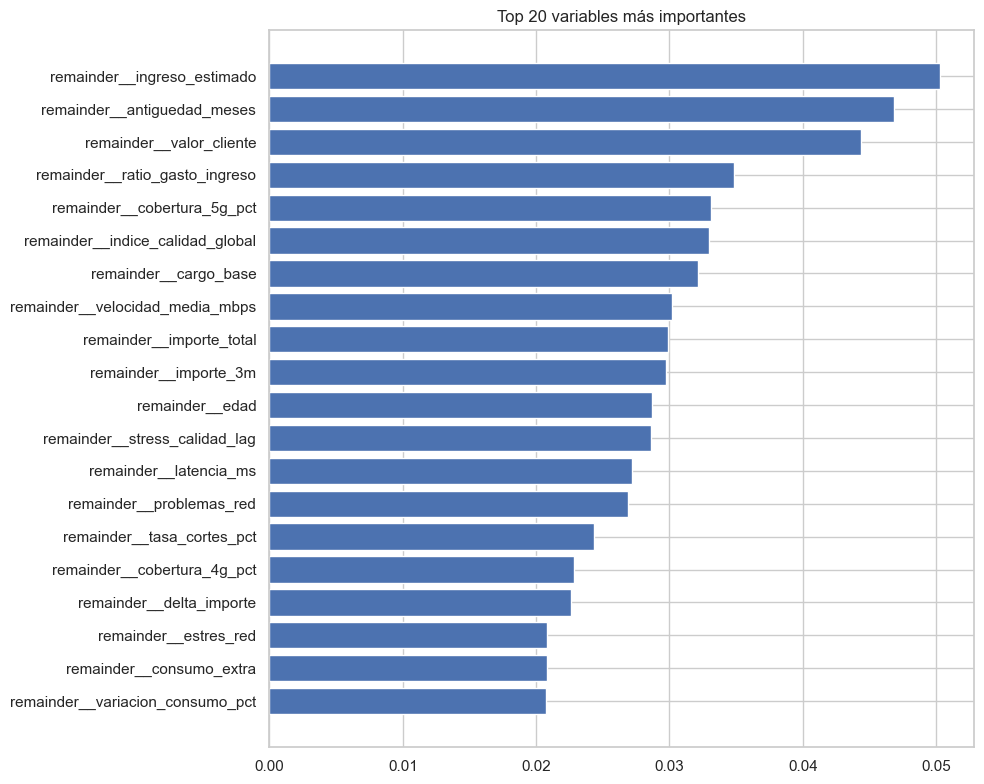

In [262]:
import matplotlib.pyplot as plt

top20 = importance_df.head(20)

plt.figure(figsize=(10,8))

plt.barh(
    top20['variable'],
    top20['importancia']
)

plt.gca().invert_yaxis()

plt.title(
    'Top 20 variables más importantes'
)

plt.tight_layout()

plt.show()

In [264]:
y_prob = pipeline.predict_proba(X_test)[:,1]

In [265]:


y_pred_03 = (y_prob >= 0.30).astype(int)

print(classification_report(y_test, y_pred_03))

              precision    recall  f1-score   support

           0       0.99      0.64      0.78     66123
           1       0.03      0.67      0.06      1196

    accuracy                           0.64     67319
   macro avg       0.51      0.66      0.42     67319
weighted avg       0.97      0.64      0.76     67319



In [267]:
y_pred_025 = (y_prob >= 0.25).astype(int)
print(classification_report(y_test, y_pred_025))

              precision    recall  f1-score   support

           0       0.99      0.50      0.66     66123
           1       0.03      0.78      0.05      1196

    accuracy                           0.50     67319
   macro avg       0.51      0.64      0.36     67319
weighted avg       0.97      0.50      0.65     67319



El modelo Random Forest obtuvo el mejor rendimiento global con un ROC-AUC de 0.7182. Aunque utilizando el umbral estándar de clasificación (0.5) la capacidad de detección de clientes en riesgo era limitada, la optimización del umbral hasta 0.30 permitió incrementar el recall de la clase minoritaria desde aproximadamente un 14% hasta un 67%, mejorando significativamente la capacidad del sistema para identificar potenciales abandonos. Este comportamiento resulta especialmente relevante en escenarios de churn, donde el coste de no detectar un cliente que abandona suele ser superior al de generar falsos positivos.

In [269]:
'churn' in X.columns

True

In [270]:
X = X.drop(columns=['churn'])

In [271]:
df_modelo_temp[['churn','churn_3m']].corr()

,churn,churn_3m
churn,1.00,-0.00
churn_3m,-0.00,1.00


In [273]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('preprocessing', preprocessing),

    ('model', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

param_dist = {
    'model__n_estimators': [300, 500, 700],
    'model__max_depth': [10, 15, 20, None],
    'model__min_samples_leaf': [5, 10, 20],
    'model__min_samples_split': [2, 5, 10],
    'model__max_features': ['sqrt', 'log2']
}

search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring='roc_auc',
    cv=2,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print(search.best_params_)
print(search.best_score_)

best_model = search.best_estimator_

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Fitting 2 folds for each of 10 candidates, totalling 20 fits
{'model__n_estimators': 300, 'model__min_samples_split': 10, 'model__min_samples_leaf': 10, 'model__max_features': 'sqrt', 'model__max_depth': None}
0.7358588385271858
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     66123
           1       0.95      0.02      0.03      1196

    accuracy                           0.98     67319
   macro avg       0.97      0.51      0.51     67319
weighted avg       0.98      0.98      0.97     67319

[[66122     1]
 [ 1175    21]]
ROC-AUC: 0.8059646315367371


In [274]:
y_prob = best_model.predict_proba(X_test)[:,1]

In [ ]:
y_pred_30 = (y_prob >= 0.30).astype(int)

print(classification_report(y_test, y_pred_30))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99     66123
           1       0.20      0.10      0.13      1196

    accuracy                           0.98     67319
   macro avg       0.59      0.55      0.56     67319
weighted avg       0.97      0.98      0.97     67319



In [276]:
y_pred_25 = (y_prob >= 0.25).astype(int)

print(classification_report(y_test, y_pred_25))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     66123
           1       0.14      0.16      0.15      1196

    accuracy                           0.97     67319
   macro avg       0.56      0.57      0.57     67319
weighted avg       0.97      0.97      0.97     67319



In [277]:
y_pred_20 = (y_prob >= 0.20).astype(int)

print(classification_report(y_test, y_pred_20))

              precision    recall  f1-score   support

           0       0.99      0.95      0.97     66123
           1       0.10      0.30      0.15      1196

    accuracy                           0.94     67319
   macro avg       0.54      0.62      0.56     67319
weighted avg       0.97      0.94      0.95     67319



El modelo presenta una elevada capacidad discriminativa, alcanzando un ROC-AUC de 0.806, lo que indica una adecuada separación entre clientes con riesgo de abandono y clientes que permanecen activos.

Dado el fuerte desbalanceo existente en la variable objetivo, la clasificación utilizando el umbral estándar de 0.5 genera un recall reducido para la clase minoritaria. Por este motivo se evaluaron distintos umbrales de decisión, observándose que un umbral de 0.20 incrementa significativamente la capacidad de detección de clientes con riesgo de abandono, alcanzando un recall cercano al 30%.

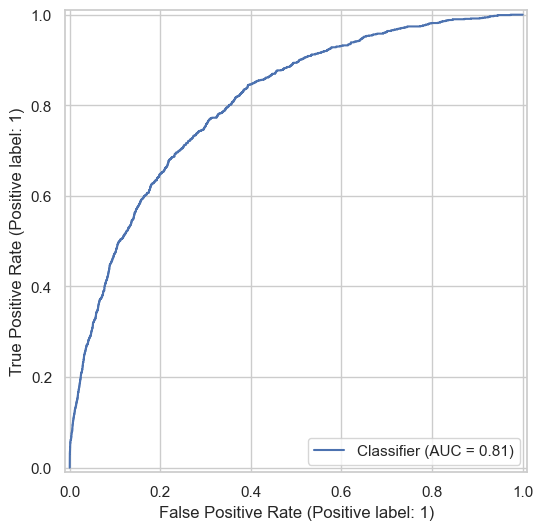

In [278]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)
plt.show()

In [280]:

y_prob_train = best_model.predict_proba(X_train)[:,1]
y_prob_test = best_model.predict_proba(X_test)[:,1]

print("ROC Train:", roc_auc_score(y_train, y_prob_train))
print("ROC Test :", roc_auc_score(y_test, y_prob_test))

ROC Train: 0.9999981016805763
ROC Test : 0.8059646315367371


In [287]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print(scores)
print(scores.mean())
print(scores.std())

[0.64715072 0.64138579 0.6404615  0.65867677 0.64077101]
0.6456891577908141
0.006940456747212353


In [288]:
print(df_modelo_temp['mes'].min())
print(df_modelo_temp['mes'].max())

2023-01-01 00:00:00
2025-12-01 00:00:00


In [289]:
df_modelo_temp['mes'].nunique()

36

In [290]:
print(df_modelo_temp['churn_3m'].mean())

0.017766158142574904


In [291]:
df_modelo_temp.groupby(df_modelo_temp['mes'].dt.year)['churn_3m'].mean()

mes
2023   0.02
2024   0.02
2025   0.01
Name: churn_3m, dtype: float64

In [293]:
# ==========================================================
# SPLIT TEMPORAL
# ==========================================================

fecha_corte = '2025-01-01'

train = df_modelo_temp[
    df_modelo_temp['mes'] < fecha_corte
].copy()

test = df_modelo_temp[
    df_modelo_temp['mes'] >= fecha_corte
].copy()

print("Train:", train.shape)
print("Test :", test.shape)

print("\nChurn Train:")
print(train['churn_3m'].mean())

print("\nChurn Test:")
print(test['churn_3m'].mean())

Train: (232646, 63)
Test : (103949, 63)

Churn Train:
0.020051924382968114

Churn Test:
0.012650434347612772


In [294]:
# ==========================================================
# VARIABLES
# ==========================================================

X_train = train.drop(
    columns=[
        'churn_3m',
        'cliente_id',
        'mes'
    ],
    errors='ignore'
)

y_train = train['churn_3m']

X_test = test.drop(
    columns=[
        'churn_3m',
        'cliente_id',
        'mes'
    ],
    errors='ignore'
)

y_test = test['churn_3m']

In [295]:
categoricas = [
    'zona_id',
    'tipo_plan',
    'region',
    'tipo_zona',
    'sexo',
    'estado_civil',
    'tipo_dispositivo'
]

In [296]:
categoricas = [
    'zona_id',
    'tipo_plan',
    'region',
    'tipo_zona',
    'sexo',
    'estado_civil',
    'tipo_dispositivo'
]

In [297]:
pipeline = Pipeline([
    ('preprocessing', preprocessing),

    ('model',
     RandomForestClassifier(
         n_estimators=300,
         max_depth=None,
         min_samples_split=10,
         min_samples_leaf=10,
         max_features='sqrt',
         class_weight='balanced',
         random_state=42,
         n_jobs=-1
     ))
])

In [298]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains

In [299]:
y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:,1]

In [300]:


print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(
    "ROC-AUC:",
    round(
        roc_auc_score(y_test, y_prob),
        4
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99    102634
           1       0.00      0.00      0.00      1315

    accuracy                           0.99    103949
   macro avg       0.49      0.50      0.50    103949
weighted avg       0.97      0.99      0.98    103949

[[102634      0]
 [  1315      0]]
ROC-AUC: 0.6565
